# VIX Futures Roll Trading Strategy — Full Backtest (v3)

**Based on Buehler & Cusatis (2018)**

**v3 changes vs v2:**
- Fixed data-loading cell (was accidentally set to `raw` → now executable `code`)
- SVXY leverage adjustment: post-27 Feb 2018, SVXY switched from −1× to −0.5×.
  We create `SVXY_ret_adj` that scales post-change returns by 2× to simulate −1× exposure.
- Improved trading-days-to-expiry: uses actual trading days from the dataset (holiday-aware)
  instead of `np.busday_count` (weekend-only)
- Added term-structure diagnostics (roll transitions, Exhibit 3 replication, pre-2008 cross-check)
- Grid search now penalises parameter combos with < 20 trades
- Clarified cost-backtest rebalancing (allocation drift, not constant-weight)

1. Load & clean VIX futures data (inc. pre-2008 ÷10 fix)
2. Validate term structure (diagnostics for Claude review)
3. Replicate Buehler OOS (Oct 2011 – Dec 2016)
4. Train until end-2016, test 2017+ (Volmageddon & COVID out-of-sample)
5. Portfolio blend: SPX + Vol strategy with weight optimisation

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import os, glob, re, warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

try:
    import yfinance as yf
except ImportError:
    !pip install yfinance
    import yfinance as yf

print('All imports OK')

All imports OK


## 2. Configuration

In [2]:
VIX_FUTURES_DIR = 'data/vix_futures'

BUEHLER_SHORT =  0.0197
BUEHLER_LONG  = -0.2400

BUEHLER_OOS_START = '2011-10-04'
BUEHLER_OOS_END   = '2016-12-30'

# Train/test split for our own optimisation
TRAIN_END   = '2016-12-30'
TEST_START  = '2017-01-03'

# SVXY changed from -1x to -0.5x on 28 Feb 2018 (effective after Volmageddon)
SVXY_LEVERAGE_CHANGE_DATE = '2018-02-28'

MONTH_CODES = {
    'F':1,'G':2,'H':3,'J':4,'K':5,'M':6,
    'N':7,'Q':8,'U':9,'V':10,'X':11,'Z':12
}

print('Config loaded.')

Config loaded.


## 3. Load VIX Futures Data (with pre-2008 price fix)

The old CBOE archive files (2006–2007) have settle/close prices that are ~10× too high
(e.g. 130–216 instead of 13–21.6). We detect and correct this by dividing by 10
whenever a row's settle price exceeds 90 (the VIX has never closed above ~83).
This is done **per-row** rather than per-contract, because some contracts have mixed
scaling (10× early on, normal prices near expiry).

In [3]:
def parse_expiration_from_filename(fname):
    base = os.path.basename(fname)
    m = re.match(r'VX_(\d{4}-\d{2}-\d{2})\.csv', base)
    if m:
        return pd.Timestamp(m.group(1))
    m = re.match(r'CFE_([A-Z])(\d{2})_VX\.csv', base)
    if m:
        month_code, yy = m.group(1), int(m.group(2))
        year = 2000 + yy
        month = MONTH_CODES.get(month_code)
        if month is None:
            return None
        # Third Wednesday of expiry month (standard VIX settlement)
        first_day = pd.Timestamp(year, month, 1)
        wed_offset = (2 - first_day.weekday()) % 7
        third_wed = first_day + pd.Timedelta(days=wed_offset + 14)
        return third_wed
    return None


def load_single_contract(fpath):
    try:
        df = pd.read_csv(fpath)
    except Exception:
        return None
    df.columns = df.columns.str.strip()
    if df['Trade Date'].str.contains('/').any():
        df['Trade Date'] = pd.to_datetime(df['Trade Date'], format='%m/%d/%Y')
    else:
        df['Trade Date'] = pd.to_datetime(df['Trade Date'])
    df = df.rename(columns={'Trade Date': 'date'})
    expiry = parse_expiration_from_filename(fpath)
    if expiry is None:
        return None
    df['expiry'] = expiry

    # Use Settle, fall back to Close when Settle is 0 (early 2013 files)
    df['Settle'] = pd.to_numeric(df['Settle'], errors='coerce')
    df['Close']  = pd.to_numeric(df['Close'], errors='coerce')
    df['Settle'] = df['Settle'].where(df['Settle'] > 0, df['Close'])
    df = df[df['Settle'] > 0].copy()

    # ── Pre-2008 fix: divide by 10 on a PER-ROW basis ──
    mask_scaled = df['Settle'] > 90
    df.loc[mask_scaled, 'Settle'] = df.loc[mask_scaled, 'Settle'] / 10.0
    df['_n_scaled'] = mask_scaled.sum()

    return df[['date', 'expiry', 'Settle', 'Total Volume', 'Open Interest', '_n_scaled']].copy()


all_files = sorted(glob.glob(os.path.join(VIX_FUTURES_DIR, '*.csv')))
print(f'Found {len(all_files)} VIX futures CSV files')

frames = []
total_rows_scaled = 0
for f in all_files:
    df = load_single_contract(f)
    if df is not None and len(df) > 0:
        total_rows_scaled += df['_n_scaled'].iloc[0]
        frames.append(df)

futures_all = pd.concat(frames, ignore_index=True)
futures_all = futures_all.sort_values(['date', 'expiry']).reset_index(drop=True)

print(f'Total rows: {len(futures_all):,}')
print(f'Date range: {futures_all.date.min().date()} to {futures_all.date.max().date()}')
print(f'Total individual rows with ÷10 fix: {total_rows_scaled}')

# Sanity check: no settle > 90 should remain
bad = futures_all[futures_all['Settle'] > 90]
if len(bad) > 0:
    print(f'⚠️ WARNING: {len(bad)} rows still have Settle > 90!')
else:
    print('✅ All settle prices ≤ 90 after fix')

Found 240 VIX futures CSV files
Total rows: 42,853
Date range: 2006-03-09 to 2026-04-02
Total individual rows with ÷10 fix: 1384
✅ All settle prices ≤ 90 after fix


## 4. Validate Pre-2008 Data After Fix

In [4]:
# Show yearly stats to verify the fix looks sensible
print(f'{"Year":>6} {"Days":>5} {"Contracts":>10} {"F_min":>7} {"F_med":>7} {"F_max":>7}')
for yr in range(2004, 2010):
    chunk = futures_all[futures_all['date'].dt.year == yr]
    if len(chunk) == 0:
        continue
    s = chunk['Settle']
    print(f'{yr:>6} {chunk["date"].nunique():>5} {chunk["expiry"].nunique():>10} '
          f'{s.min():>7.1f} {s.median():>7.1f} {s.max():>7.1f}')

# Compare 2006-07 to 2008-09: the ranges should be broadly similar
print('\n(For reference: VIX spot ranged 10-33 in 2006-07, 16-81 in 2008-09)')

  Year  Days  Contracts   F_min   F_med   F_max
  2006   206          9    11.9    16.1    18.2
  2007   251         21    10.0    16.3    30.6
  2008   253         22     1.0    24.6    68.0
  2009   252         20    20.8    30.6    57.9

(For reference: VIX spot ranged 10-33 in 2006-07, 16-81 in 2008-09)


## 5. Build Daily Term Structure

**v3 improvement:** Uses actual trading days from the dataset to compute days-to-expiry,
instead of `np.busday_count` which only knows about weekends but not market holidays.

In [5]:
def build_term_structure(futures_all):
    df = futures_all[futures_all['expiry'] > futures_all['date']].copy()
    df['dte'] = (df['expiry'] - df['date']).dt.days
    records = []
    for date, group in df.groupby('date'):
        g = group.sort_values('expiry')
        if len(g) < 2:
            continue
        f1, f2 = g.iloc[0], g.iloc[1]
        row = {
            'date': date,
            'F1_settle': f1['Settle'], 'F1_expiry': f1['expiry'], 'F1_dte': f1['dte'],
            'F2_settle': f2['Settle'], 'F2_expiry': f2['expiry'], 'F2_dte': f2['dte'],
        }
        # Also grab F3–F5 if available (for Exhibit 3 replication)
        for i, label in enumerate(['F3', 'F4', 'F5'], start=2):
            if len(g) > i:
                row[f'{label}_settle'] = g.iloc[i]['Settle']
                row[f'{label}_expiry'] = g.iloc[i]['expiry']
            else:
                row[f'{label}_settle'] = np.nan
                row[f'{label}_expiry'] = pd.NaT
        records.append(row)
    ts = pd.DataFrame(records)
    ts['date'] = pd.to_datetime(ts['date'])
    ts = ts.set_index('date').sort_index()
    return ts

term_structure = build_term_structure(futures_all)
print(f'Term structure: {len(term_structure)} trading days')
print(f'Range: {term_structure.index.min().date()} to {term_structure.index.max().date()}')

# Build set of actual trading days for holiday-aware DTE
ALL_TRADING_DAYS = term_structure.index.sort_values()

def trading_days_between(d1, d2):
    """Count actual trading days between d1 (exclusive) and d2 (inclusive)."""
    return int(((ALL_TRADING_DAYS > d1) & (ALL_TRADING_DAYS <= d2)).sum())

# Compute holiday-aware trading days to expiry for F1
term_structure['F1_tdte'] = term_structure.apply(
    lambda r: max(trading_days_between(r.name, r['F1_expiry']), 1), axis=1
)

# Check for remaining gaps
all_bdays = pd.bdate_range(term_structure.index.min(), term_structure.index.max())
missing = all_bdays.difference(term_structure.index)
print(f'Missing business days: {len(missing)}  (holidays + data gaps)')

Term structure: 5015 trading days
Range: 2006-03-23 to 2026-04-02
Missing business days: 211  (holidays + data gaps)


## 6. Term Structure Diagnostics

### 📋 SHARE THESE OUTPUTS for validation

In [6]:
# ── Diagnostic 1: Head & tail of term structure ──
print('=== FIRST 20 ROWS ===')
print(term_structure[['F1_settle', 'F1_expiry', 'F1_dte', 'F1_tdte', 'F2_settle']].head(20).to_string())
print('\n=== LAST 20 ROWS ===')
print(term_structure[['F1_settle', 'F1_expiry', 'F1_dte', 'F1_tdte', 'F2_settle']].tail(20).to_string())

=== FIRST 20 ROWS ===
            F1_settle  F1_expiry  F1_dte  F1_tdte  F2_settle
date                                                        
2006-03-23      16.07 2007-02-21     335      229      17.16
2006-03-24      16.07 2007-02-21     334      228      17.01
2006-03-27      16.03 2007-02-21     331      227      17.00
2006-03-28      16.01 2007-02-21     330      226      17.01
2006-03-29      15.92 2007-02-21     329      225      16.97
2006-03-30      15.81 2007-02-21     328      224      16.88
2006-03-31      15.76 2007-02-21     327      223      16.84
2006-04-03      15.74 2007-02-21     324      222      16.88
2006-04-04      15.64 2007-02-21     323      221      16.83
2006-04-05      15.70 2007-02-21     322      220      16.80
2006-04-06      15.65 2007-02-21     321      219      16.76
2006-04-07      15.51 2007-02-21     320      218      16.66
2006-04-10      15.45 2007-02-21     317      217      16.56
2006-04-11      15.50 2007-02-21     316      216      16.37
20

In [7]:
# ── Diagnostic 2: Roll transitions (when F1 switches contract) ──
roll_mask = term_structure['F1_expiry'] != term_structure['F1_expiry'].shift(1)
rolls = term_structure[roll_mask][['F1_settle', 'F1_expiry', 'F1_dte', 'F1_tdte', 'F2_settle']].copy()
print(f'=== ROLL TRANSITIONS (first 30 of {len(rolls)} total) ===')
print(rolls.head(30).to_string())

=== ROLL TRANSITIONS (first 30 of 232 total) ===
            F1_settle  F1_expiry  F1_dte  F1_tdte  F2_settle
date                                                        
2006-03-23      16.07 2007-02-21     335      229      17.16
2006-10-23      14.08 2007-01-17      86       57      14.60
2007-01-17      11.91 2007-02-21      35       24      12.90
2007-02-15      11.55 2007-03-21      34       23      12.61
2007-03-21      13.28 2007-04-18      28       19      13.60
2007-04-18      13.13 2007-05-16      28       20      13.37
2007-05-16      14.06 2007-06-20      35       24      14.50
2007-06-20      15.03 2007-07-18      28       19      15.13
2007-07-18      17.37 2007-08-15      28       20      17.42
2007-08-15      25.18 2007-09-19      35       24      22.81
2007-09-19      20.57 2007-10-17      28       20      20.23
2007-10-17      21.07 2007-11-21      35       25      20.95
2007-11-21      26.81 2007-12-19      28       19      26.74
2007-12-19      24.42 2008-01-16    

### Diagnostic 3: Pre-2008 Cross-Check vs VIX Spot

After the ÷10 fix, the spread between F1 and VIX spot should generally be 0–15% in contango.
If we see F1 values that are 2× VIX, there are still scaling issues.

In [8]:
# This check runs after VIX spot is merged (Section 8).
# Placeholder — see Diagnostic 3 cell below.

## 7. Download VIX Spot & ETF Prices

In [9]:
def dl(ticker, start='2004-01-01', end='2026-12-31'):
    tmp = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    tmp = tmp[['Close']]
    if isinstance(tmp.columns, pd.MultiIndex):
        tmp.columns = tmp.columns.get_level_values(0)
    tmp.index = pd.to_datetime(tmp.index)
    if hasattr(tmp.index, 'levels'):
        tmp.index = tmp.index.get_level_values(0)
    tmp.index.name = 'date'
    return tmp

# 1. Fast, efficient load of VIX spot from the CBOE CSV
vix = pd.read_csv(
    'data/vix_history.csv', 
    usecols=['DATE', 'CLOSE'], 
    index_col='DATE', 
    parse_dates=['DATE']
).rename(columns={'CLOSE': 'VIX'})

vix.index.name = 'date'

# 2. Load SVXY, VIXY, and SPY from yfinance
svxy = dl('SVXY').rename(columns={'Close': 'SVXY'})
vixy = dl('VIXY').rename(columns={'Close': 'VIXY'})
spy  = dl('SPY').rename(columns={'Close': 'SPY'})

for name, df in [('VIX', vix), ('SVXY', svxy), ('VIXY', vixy), ('SPY', spy)]:
    print(f'{name:5s}: {len(df)} rows, {df.index.min().date()} to {df.index.max().date()}')

VIX  : 9156 rows, 1990-01-02 to 2026-04-02
SVXY : 3645 rows, 2011-10-04 to 2026-04-02
VIXY : 3834 rows, 2011-01-04 to 2026-04-02
SPY  : 5598 rows, 2004-01-02 to 2026-04-02


## 8. Merge All Data & Compute Daily Roll

**v3 change:** Added `SVXY_ret_adj` which scales SVXY returns by 2× after the
leverage change date (28 Feb 2018) to simulate the original −1× exposure.
The raw `SVXY_ret` is kept for reference.

In [10]:
data = term_structure.join(vix, how='inner')
data = data.join(svxy, how='left').join(vixy, how='left').join(spy, how='left')

# Daily roll: (F1 - VIX) / trading days to settlement
# Positive in contango, negative in backwardation
data['daily_roll'] = (data['F1_settle'] - data['VIX']) / data['F1_tdte']

# ETF daily returns
data['SVXY_ret'] = data['SVXY'].pct_change()
data['VIXY_ret'] = data['VIXY'].pct_change()
data['SPY_ret']  = data['SPY'].pct_change()

# ── SVXY leverage adjustment (v3) ──
# Before 2018-02-28: SVXY was -1x daily → use raw returns
# After  2018-02-28: SVXY is  -0.5x daily → multiply by 2 to simulate -1x
data['SVXY_ret_adj'] = data['SVXY_ret'].copy()
post_lev = data.index >= SVXY_LEVERAGE_CHANGE_DATE
data.loc[post_lev, 'SVXY_ret_adj'] = data.loc[post_lev, 'SVXY_ret'] * 2.0

n_adj = post_lev.sum()
print(f'SVXY leverage adjustment: {n_adj} rows scaled by 2x (from {SVXY_LEVERAGE_CHANGE_DATE})')

# Futures return — only on same-contract days (exclude roll-day jumps)
data['F1_ret_raw'] = data['F1_settle'].pct_change()
data['F1_same_contract'] = data['F1_expiry'] == data['F1_expiry'].shift(1)
data['F1_ret'] = data['F1_ret_raw'].where(data['F1_same_contract'], 0.0)

print(f'Merged dataset: {len(data)} rows')
print(f'Range: {data.index.min().date()} to {data.index.max().date()}')

SVXY leverage adjustment: 2036 rows scaled by 2x (from 2018-02-28)
Merged dataset: 5013 rows
Range: 2006-03-23 to 2026-04-02


### Diagnostic 3 (actual): Pre-2008 F1 vs VIX Spot Cross-Check

In [11]:
# After the ÷10 fix, F1/VIX ratio should be ~1.0–1.15 in normal contango
early = data.loc['2007':'2007', ['VIX', 'F1_settle']].dropna()
if len(early) > 0:
    early['ratio'] = early['F1_settle'] / early['VIX']
    print(f'=== 2004–2007: F1 / VIX Spot Ratio ===')
    print(f'  Mean:  {early["ratio"].mean():.3f}')
    print(f'  Min:   {early["ratio"].min():.3f}')
    print(f'  Max:   {early["ratio"].max():.3f}')
    print(f'  Std:   {early["ratio"].std():.3f}')
    n_suspicious = (early['ratio'] > 1.5).sum() + (early['ratio'] < 0.5).sum()
    if n_suspicious > 0:
        print(f'  ⚠️ {n_suspicious} rows with ratio > 1.5 or < 0.5 — possible remaining scale issues')
        print(early[early['ratio'] > 1.5].head(10))
    else:
        print(f'  ✅ All ratios between 0.5 and 1.5 — fix looks good')
else:
    print('No 2004-2007 data available after merge.')

=== 2004–2007: F1 / VIX Spot Ratio ===
  Mean:  1.011
  Min:   0.809
  Max:   1.251
  Std:   0.064
  ✅ All ratios between 0.5 and 1.5 — fix looks good


### Diagnostic 4: Replicate Exhibit 3 — Contango/Backwardation Stats (Jan 2007–Dec 2016)

**Paper reports (nearest contract):** 1907 days contango, 604 days backwardation, 2518 total.
Average spread: 4%, max: 29%, min: −38%.

In [12]:
buehler_period = data.loc['2007-01-01':'2016-12-31'].copy()
n_total = len(buehler_period)

print(f'=== Exhibit 3 Replication: Jan 2007 – Dec 2016 ===')
print(f'Total trading days: {n_total}  (paper: 2518)')

# Nearest contract (F1)
contango_f1 = (buehler_period['F1_settle'] > buehler_period['VIX']).sum()
backw_f1    = (buehler_period['F1_settle'] <= buehler_period['VIX']).sum()
spread_f1   = (buehler_period['F1_settle'] - buehler_period['VIX']) / buehler_period['VIX']

print(f'\nNearest contract (F1):')
print(f'  Days contango:      {contango_f1}  (paper: 1907)')
print(f'  Days backwardation: {backw_f1}  (paper: 604)')
print(f'  Ratio:              {contango_f1}:{backw_f1} = {contango_f1/max(backw_f1,1):.1f}:1  (paper: 3.2:1)')
print(f'  Avg spread:         {spread_f1.mean():.2%}  (paper: 4%)')
print(f'  Max spread:         {spread_f1.max():.2%}  (paper: 29%)')
print(f'  Min spread:         {spread_f1.min():.2%}  (paper: -38%)')

# Next contract (F2)
contango_f2 = (buehler_period['F2_settle'] > buehler_period['VIX']).sum()
spread_f2   = (buehler_period['F2_settle'] - buehler_period['VIX']) / buehler_period['VIX']
print(f'\nNext contract (F2):')
print(f'  Days contango:      {contango_f2}  (paper: 2023)')
print(f'  Avg spread:         {spread_f2.mean():.2%}  (paper: 5%)')

# Consecutive contango/backwardation streaks for F1
is_contango = buehler_period['F1_settle'] > buehler_period['VIX']
streaks = is_contango.ne(is_contango.shift()).cumsum()
contango_streaks = is_contango.groupby(streaks).sum()
contango_streaks = contango_streaks[contango_streaks > 0]
backw_streaks_raw = (~is_contango).groupby(streaks).sum()
backw_streaks_raw = backw_streaks_raw[backw_streaks_raw > 0]

print(f'\nConsecutive contango streaks (F1):')
print(f'  Average: {contango_streaks.mean():.1f} days  (paper: 9.49)')
print(f'  Max:     {contango_streaks.max()} days  (paper: 66)')
print(f'\nConsecutive backwardation streaks (F1):')
print(f'  Average: {backw_streaks_raw.mean():.1f} days  (paper: 3.02)')
print(f'  Max:     {backw_streaks_raw.max()} days  (paper: 68)')

=== Exhibit 3 Replication: Jan 2007 – Dec 2016 ===
Total trading days: 2491  (paper: 2518)

Nearest contract (F1):
  Days contango:      1922  (paper: 1907)
  Days backwardation: 569  (paper: 604)
  Ratio:              1922:569 = 3.4:1  (paper: 3.2:1)
  Avg spread:         4.31%  (paper: 4%)
  Max spread:         35.32%  (paper: 29%)
  Min spread:         -38.34%  (paper: -38%)

Next contract (F2):
  Days contango:      2017  (paper: 2023)
  Avg spread:         10.18%  (paper: 5%)

Consecutive contango streaks (F1):
  Average: 11.2 days  (paper: 9.49)
  Max:     87 days  (paper: 66)

Consecutive backwardation streaks (F1):
  Average: 3.3 days  (paper: 3.02)
  Max:     68 days  (paper: 68)


### Diagnostic 5: Daily Roll Distribution (2007–2016)

=== Daily Roll Distribution (Jan 2007 – Dec 2016) ===
count    2491.000000
mean        0.050551
std         0.281473
min        -6.080000
25%         0.010000
50%         0.080714
75%         0.141250
max         1.980000


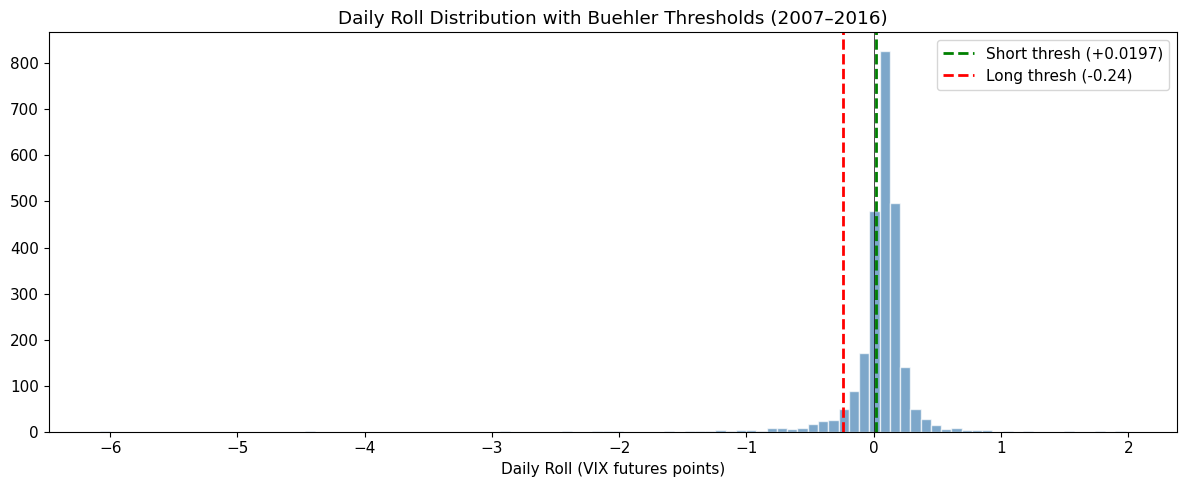


Days triggering SHORT (≥0.0197): 72.2%
Days triggering LONG  (≤-0.24): 5.6%
Days in CASH:                       22.2%


In [13]:
roll_buehler = data.loc['2007':'2016', 'daily_roll'].dropna()
print('=== Daily Roll Distribution (Jan 2007 – Dec 2016) ===')
print(roll_buehler.describe().to_string())

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(roll_buehler, bins=100, color='steelblue', edgecolor='white', alpha=0.7)
ax.axvline(BUEHLER_SHORT, color='green', ls='--', lw=2, label=f'Short thresh (+{BUEHLER_SHORT})')
ax.axvline(BUEHLER_LONG, color='red', ls='--', lw=2, label=f'Long thresh ({BUEHLER_LONG})')
ax.axvline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Daily Roll (VIX futures points)')
ax.set_title('Daily Roll Distribution with Buehler Thresholds (2007–2016)')
ax.legend()
plt.tight_layout()
plt.show()

pct_short = (roll_buehler >= BUEHLER_SHORT).mean()
pct_long  = (roll_buehler <= BUEHLER_LONG).mean()
pct_cash  = 1 - pct_short - pct_long
print(f'\nDays triggering SHORT (≥{BUEHLER_SHORT}): {pct_short:.1%}')
print(f'Days triggering LONG  (≤{BUEHLER_LONG}): {pct_long:.1%}')
print(f'Days in CASH:                       {pct_cash:.1%}')

## 9. VIX Spot vs Nearest Futures & Daily Roll

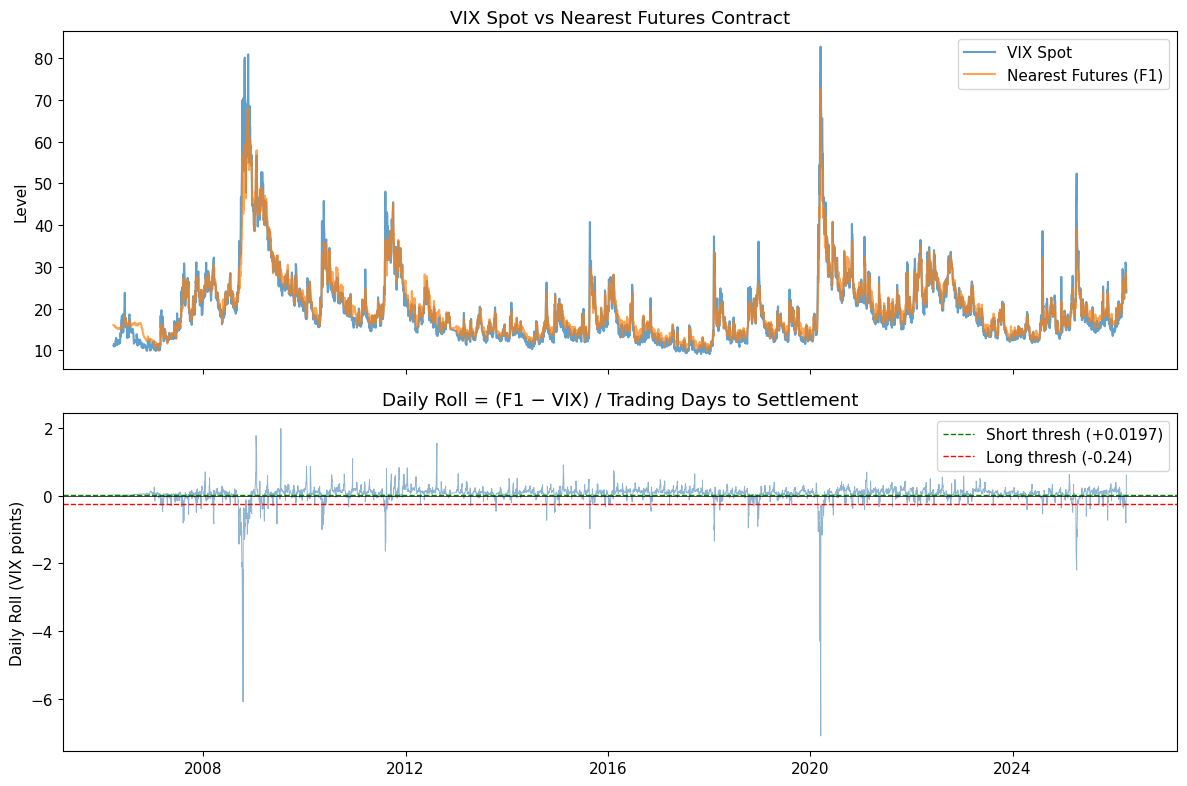

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(data.index, data['VIX'], label='VIX Spot', alpha=0.7)
axes[0].plot(data.index, data['F1_settle'], label='Nearest Futures (F1)', alpha=0.7)
axes[0].set_ylabel('Level')
axes[0].legend()
axes[0].set_title('VIX Spot vs Nearest Futures Contract')

axes[1].plot(data.index, data['daily_roll'], color='steelblue', alpha=0.6, lw=0.7)
axes[1].axhline(BUEHLER_SHORT, color='green', ls='--', lw=1, label=f'Short thresh (+{BUEHLER_SHORT})')
axes[1].axhline(BUEHLER_LONG, color='red', ls='--', lw=1, label=f'Long thresh ({BUEHLER_LONG})')
axes[1].axhline(0, color='black', ls='-', lw=0.5)
axes[1].set_ylabel('Daily Roll (VIX points)')
axes[1].set_title('Daily Roll = (F1 − VIX) / Trading Days to Settlement')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Strategy Engine

**v3 change:** Uses `SVXY_ret_adj` (leverage-adjusted) instead of raw `SVXY_ret`.

In [15]:
def generate_signals(data, short_thresh, long_thresh):
    prev_roll = data['daily_roll'].shift(1)
    signal = pd.Series('CASH', index=data.index)
    signal[prev_roll >= short_thresh] = 'SVXY'
    signal[prev_roll <= long_thresh]  = 'VIXY'
    return signal


def backtest(data, signal, label='Strategy', start=None, end=None, use_adj_svxy=True):
    df = data.loc[start:end].copy() if start else data.copy()
    sig = signal.reindex(df.index).fillna('CASH')
    df['signal'] = sig
    df = df.dropna(subset=['SVXY_ret', 'VIXY_ret'])
    if len(df) == 0:
        return pd.DataFrame(), {}

    # Select SVXY return column: adjusted (v3) or raw
    svxy_col = 'SVXY_ret_adj' if use_adj_svxy else 'SVXY_ret'

    # ETF strategy returns
    df['etf_ret'] = 0.0
    df.loc[df['signal'] == 'SVXY', 'etf_ret'] = df.loc[df['signal'] == 'SVXY', svxy_col]
    df.loc[df['signal'] == 'VIXY', 'etf_ret'] = df.loc[df['signal'] == 'VIXY', 'VIXY_ret']

    # Futures strategy returns
    df['fut_ret'] = 0.0
    df.loc[df['signal'] == 'SVXY', 'fut_ret'] = -df.loc[df['signal'] == 'SVXY', 'F1_ret']
    df.loc[df['signal'] == 'VIXY', 'fut_ret'] = df.loc[df['signal'] == 'VIXY', 'F1_ret']

    # Also track raw (unadjusted) ETF returns for comparison
    df['etf_ret_raw'] = 0.0
    df.loc[df['signal'] == 'SVXY', 'etf_ret_raw'] = df.loc[df['signal'] == 'SVXY', 'SVXY_ret']
    df.loc[df['signal'] == 'VIXY', 'etf_ret_raw'] = df.loc[df['signal'] == 'VIXY', 'VIXY_ret']

    # Equity curves
    df['etf_equity'] = (1 + df['etf_ret']).cumprod()
    df['etf_equity_raw'] = (1 + df['etf_ret_raw']).cumprod()
    df['fut_equity'] = (1 + df['fut_ret']).cumprod()
    df['spy_equity'] = (1 + df['SPY_ret']).cumprod()

    # Stats
    n = len(df); yrs = n / 252
    terminal = df['etf_equity'].iloc[-1]
    cagr = terminal ** (1/yrs) - 1 if yrs > 0 else 0
    vol = df['etf_ret'].std() * np.sqrt(252)
    sharpe = (df['etf_ret'].mean() * 252) / vol if vol > 0 else 0
    semi = df['etf_ret'][df['etf_ret'] < 0].std() * np.sqrt(252)
    sortino = (df['etf_ret'].mean() * 252) / semi if semi > 0 else 0
    dd = (df['etf_equity'] / df['etf_equity'].cummax()) - 1
    n_trades = (df['signal'] != df['signal'].shift(1)).sum()

    stats = {
        'Terminal ($1)': f'{terminal:.2f}',
        'CAGR': f'{cagr:.1%}', 'Vol (ann.)': f'{vol:.1%}',
        'Sharpe': f'{sharpe:.2f}', 'Sortino': f'{sortino:.2f}',
        'Max DD': f'{dd.min():.1%}',
        'Trades': n_trades,
        'Days Short': (df['signal']=='SVXY').sum(),
        'Days Long': (df['signal']=='VIXY').sum(),
        'Days Cash': (df['signal']=='CASH').sum(),
        'Period': f"{df.index.min().date()} to {df.index.max().date()}",
    }
    return df, stats

print('Engine ready.')

Engine ready.


## 11. Buehler Replication (Oct 2011 – Dec 2016)

Using the published thresholds (+0.0197 / −0.240).
Note: this period is entirely pre-leverage-change, so `use_adj_svxy` has no effect here.

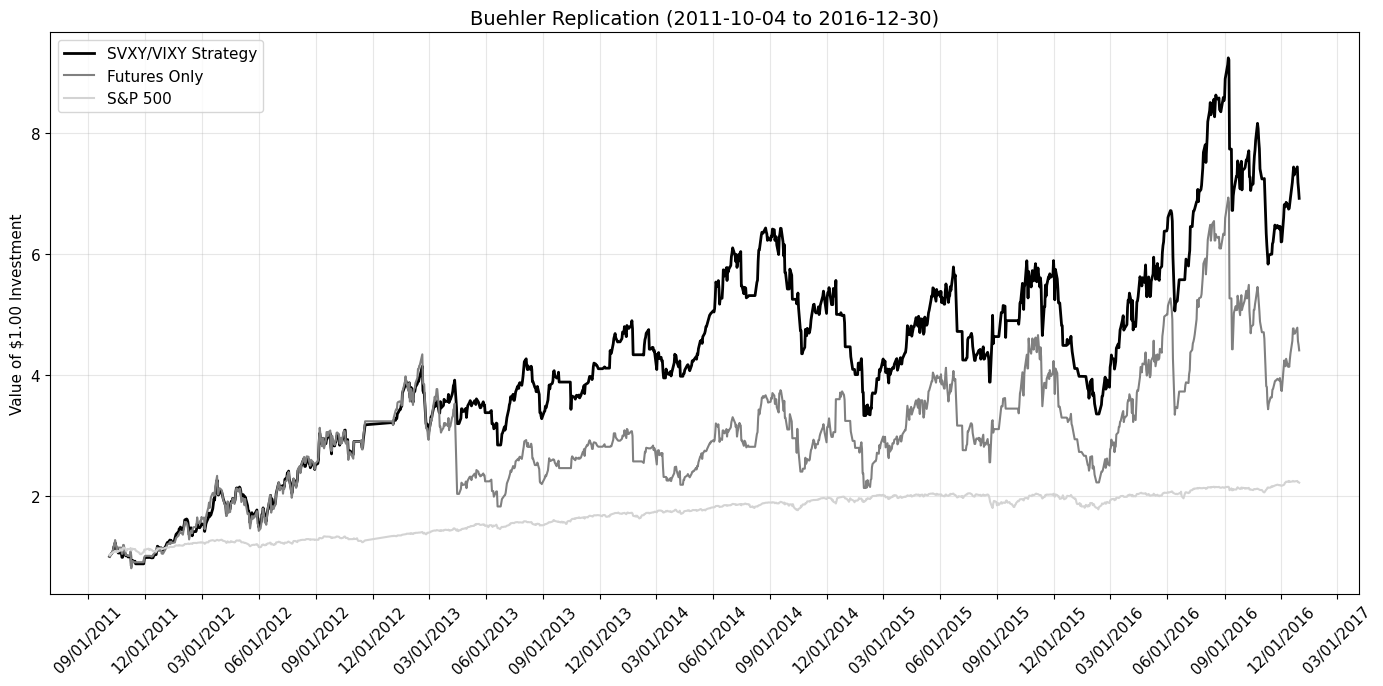


=== Buehler Replication Stats ===
  (Paper reports: Terminal=$15.23, CAGR=68.10%)
  Terminal ($1)       : 6.92
  CAGR                : 45.8%
  Vol (ann.)          : 53.8%
  Sharpe              : 0.98
  Sortino             : 1.10
  Max DD              : -48.2%
  Trades              : 163
  Days Short          : 1058
  Days Long           : 26
  Days Cash           : 208
  Period              : 2011-10-05 to 2016-12-30


In [16]:
sig_buehler = generate_signals(data, BUEHLER_SHORT, BUEHLER_LONG)
bt_b, stats_b = backtest(data, sig_buehler, 'Buehler ETF',
                          start=BUEHLER_OOS_START, end=BUEHLER_OOS_END)

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(bt_b.index, bt_b['etf_equity'], 'k-', lw=2, label='SVXY/VIXY Strategy')
ax.plot(bt_b.index, bt_b['fut_equity'], color='gray', lw=1.5, label='Futures Only')
ax.plot(bt_b.index, bt_b['spy_equity'], color='lightgray', lw=1.5, label='S&P 500')
ax.set_title(f'Buehler Replication ({BUEHLER_OOS_START} to {BUEHLER_OOS_END})', fontsize=14)
ax.set_ylabel('Value of $1.00 Investment')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\n=== Buehler Replication Stats ===')
print(f'  (Paper reports: Terminal=$15.23, CAGR=68.10%)')
for k, v in stats_b.items():
    print(f'  {k:20s}: {v}')

## 12. Threshold Optimisation (80/20 Train/Test Split)

Grid search optimising **Sharpe ratio** on the first 80% of ETF data.

**v3 change:** Combos with fewer than 20 trades are penalised (Sharpe set to −999)
to avoid corner solutions that trade once in 5 years.

ETF data: 2011-10-04 to 2026-04-02 (3618 days)
Train (80%): 2011-10-04 to 2023-05-12 (2894 days)
Test  (20%): 2023-05-15 to 2026-04-02 (724 days)
  Volmageddon: ❌ in train
  COVID: ❌ in train

=== Optimal Thresholds (Train Set, max Sharpe, ≥20 trades) ===
  Short: 0.0300  (Buehler: 0.0197)
  Long:  -0.4000  (Buehler: -0.24)
  Sharpe: 1.060
  Terminal: $129.71
  Max DD: -63.2%
  Trades: 422


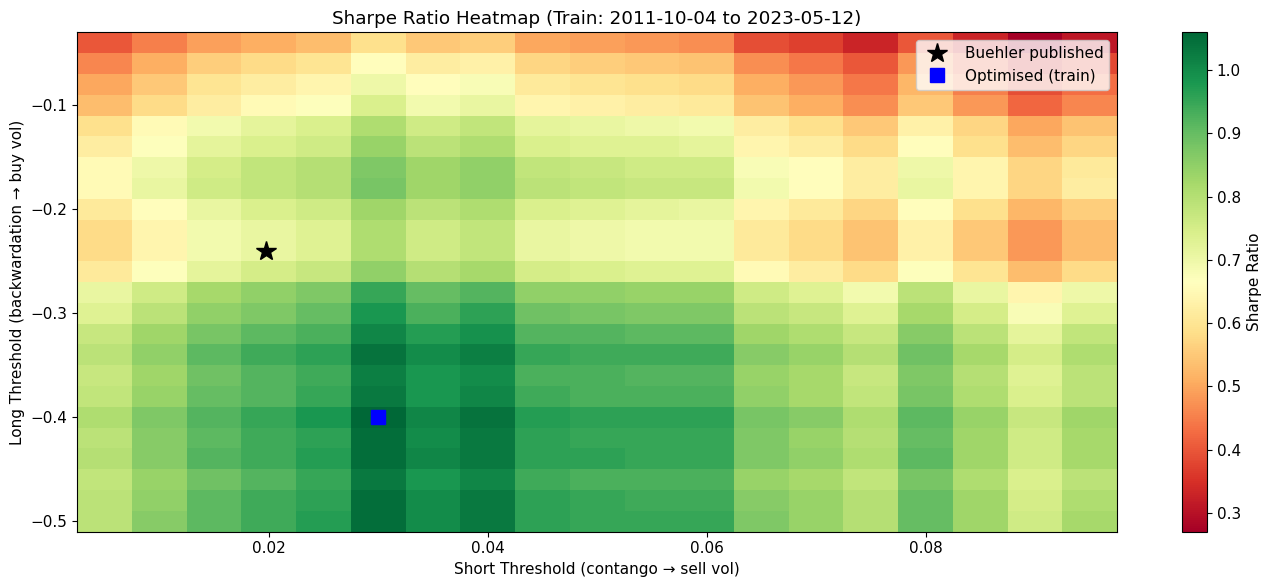

In [17]:
etf_data = data.dropna(subset=['SVXY', 'VIXY']).copy()
etf_start = etf_data.index.min().strftime('%Y-%m-%d')

# 80/20 split
split_idx = int(len(etf_data) * 0.80)
train_end = etf_data.index[split_idx - 1]
test_start = etf_data.index[split_idx]
train_end_str = train_end.strftime('%Y-%m-%d')
test_start_str = test_start.strftime('%Y-%m-%d')

print(f'ETF data: {etf_start} to {etf_data.index.max().date()} ({len(etf_data)} days)')
print(f'Train (80%): {etf_start} to {train_end.date()} ({split_idx} days)')
print(f'Test  (20%): {test_start.date()} to {etf_data.index.max().date()} ({len(etf_data) - split_idx} days)')

# Check key events
for evt, dt in [('Volmageddon', '2018-02-05'), ('COVID', '2020-03-16')]:
    print(f'  {evt}: {"✅ OOS" if pd.Timestamp(dt) >= test_start else "❌ in train"}')

MIN_TRADES = 20  # v3: minimum trades to avoid degenerate solutions

short_grid = np.arange(0.005, 0.10, 0.005)
long_grid  = np.arange(-0.50, -0.02, 0.02)

results = []
for st in short_grid:
    for lt in long_grid:
        sig = generate_signals(data, st, lt)
        bt_tmp, stats_tmp = backtest(data, sig, '', start=etf_start, end=train_end_str)
        if len(bt_tmp) == 0:
            continue
        n_trades = int(stats_tmp['Trades'])
        sharpe = float(stats_tmp['Sharpe'])
        # Penalise degenerate combos
        if n_trades < MIN_TRADES:
            sharpe = -999
        results.append({
            'short_thresh': round(st, 4),
            'long_thresh': round(lt, 4),
            'sharpe': sharpe,
            'terminal': bt_tmp['etf_equity'].iloc[-1],
            'max_dd': (bt_tmp['etf_equity'] / bt_tmp['etf_equity'].cummax() - 1).min(),
            'trades': n_trades,
        })

res_df = pd.DataFrame(results)
# Exclude penalised rows from best selection
valid = res_df[res_df['sharpe'] > -900]
best = valid.loc[valid['sharpe'].idxmax()]
OPT_SHORT = best['short_thresh']
OPT_LONG  = best['long_thresh']

print(f'\n=== Optimal Thresholds (Train Set, max Sharpe, ≥{MIN_TRADES} trades) ===')
print(f'  Short: {OPT_SHORT:.4f}  (Buehler: {BUEHLER_SHORT})')
print(f'  Long:  {OPT_LONG:.4f}  (Buehler: {BUEHLER_LONG})')
print(f'  Sharpe: {best["sharpe"]:.3f}')
print(f'  Terminal: ${best["terminal"]:.2f}')
print(f'  Max DD: {best["max_dd"]:.1%}')
print(f'  Trades: {best["trades"]:.0f}')

# Heatmap (use valid only)
pivot = valid.pivot_table(values='sharpe', index='long_thresh', columns='short_thresh')
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.pcolormesh(pivot.columns, pivot.index, pivot.values, cmap='RdYlGn', shading='auto')
ax.plot(BUEHLER_SHORT, BUEHLER_LONG, 'k*', markersize=15, label='Buehler published')
ax.plot(OPT_SHORT, OPT_LONG, 'bs', markersize=10, label='Optimised (train)')
ax.set_xlabel('Short Threshold (contango → sell vol)')
ax.set_ylabel('Long Threshold (backwardation → buy vol)')
ax.set_title(f'Sharpe Ratio Heatmap (Train: {etf_start} to {train_end_str})')
ax.legend(fontsize=11)
plt.colorbar(im, label='Sharpe Ratio')
plt.tight_layout()
plt.show()

## 13. Out-of-Sample Test (2017 – Present)

Both **Volmageddon (Feb 2018)** and **COVID (Mar 2020)** are fully out-of-sample.
We compare: optimised thresholds, Buehler's originals, and show adjusted vs raw SVXY.

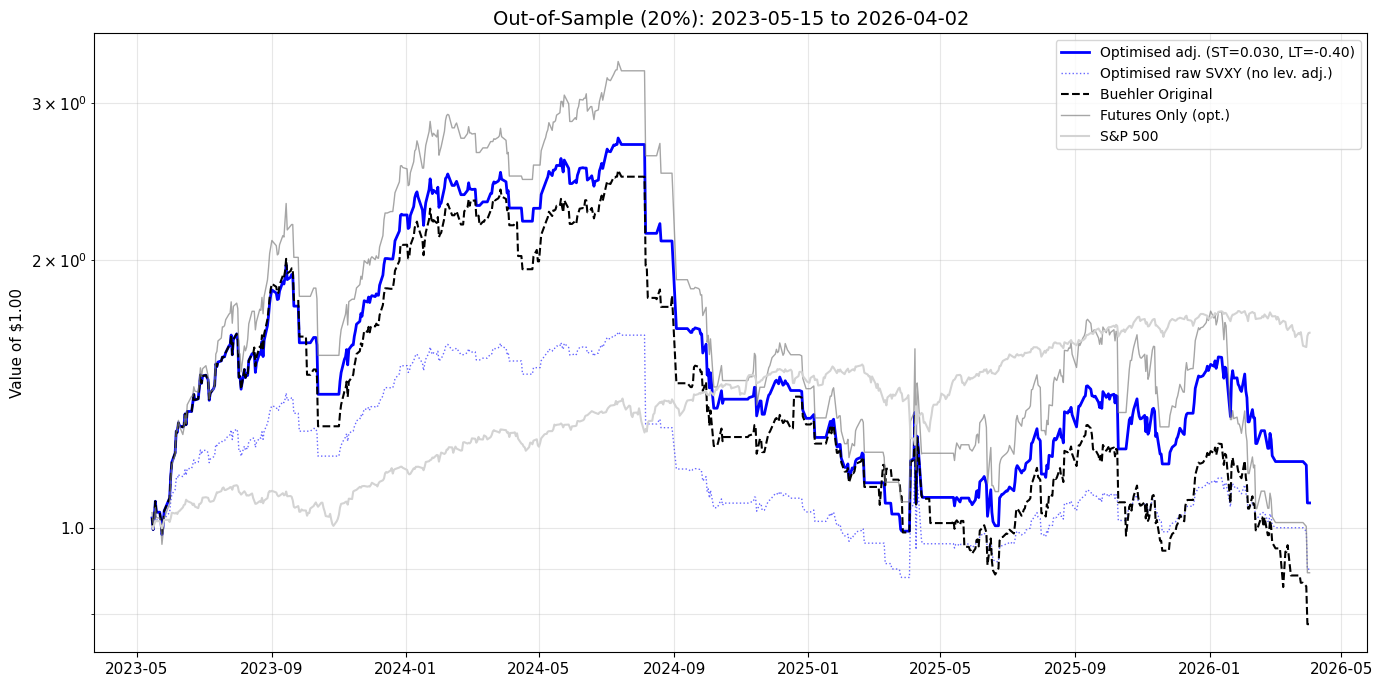


=== Out-of-Sample Results ===


,Terminal ($1),CAGR,Vol (ann.),Sharpe,Sortino,Max DD,Trades,Days Short,Days Long,Days Cash,Period
Optimised (adj),1.07,2.3%,46.4%,0.29,0.25,-63.8%,122,464,16,245,2023-05-15 to 2026-04-02
Buehler Original,0.78,-8.3%,49.9%,0.08,0.08,-69.1%,133,489,31,205,2023-05-15 to 2026-04-02


In [18]:
test_end = etf_data.index.max().strftime('%Y-%m-%d')

sig_opt = generate_signals(data, OPT_SHORT, OPT_LONG)
bt_opt, stats_opt = backtest(data, sig_opt, 'Optimised', start=test_start_str, end=test_end)

sig_buehler_test = generate_signals(data, BUEHLER_SHORT, BUEHLER_LONG)
bt_buehler_test, stats_buehler_test = backtest(data, sig_buehler_test, 'Buehler',
                                                start=test_start_str, end=test_end)

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(bt_opt.index, bt_opt['etf_equity'], 'b-', lw=2,
        label=f'Optimised adj. (ST={OPT_SHORT:.3f}, LT={OPT_LONG:.2f})')
ax.plot(bt_opt.index, bt_opt['etf_equity_raw'], 'b:', lw=1, alpha=0.6,
        label='Optimised raw SVXY (no lev. adj.)')
ax.plot(bt_buehler_test.index, bt_buehler_test['etf_equity'], 'k--', lw=1.5,
        label='Buehler Original')
ax.plot(bt_opt.index, bt_opt['fut_equity'], color='gray', lw=1, alpha=0.7,
        label='Futures Only (opt.)')
ax.plot(bt_opt.index, bt_opt['spy_equity'], color='lightgray', lw=1.5, label='S&P 500')

for dt, lbl in [('2018-02-05', 'Volmageddon'), ('2020-03-16', 'COVID')]:
    evt = pd.Timestamp(dt)
    if evt >= bt_opt.index.min() and evt <= bt_opt.index.max():
        ax.axvline(evt, color='red', ls=':', alpha=0.5)
        ax.text(evt, ax.get_ylim()[1]*0.85, f' {lbl}', fontsize=9, color='red')

ax.set_title(f'Out-of-Sample (20%): {test_start_str} to {test_end}', fontsize=14)
ax.set_ylabel('Value of $1.00')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

comp = pd.DataFrame({'Optimised (adj)': stats_opt, 'Buehler Original': stats_buehler_test}).T
print('\n=== Out-of-Sample Results ===')
display(comp)

## 14. Full Period Equity Curve (Train + Test)

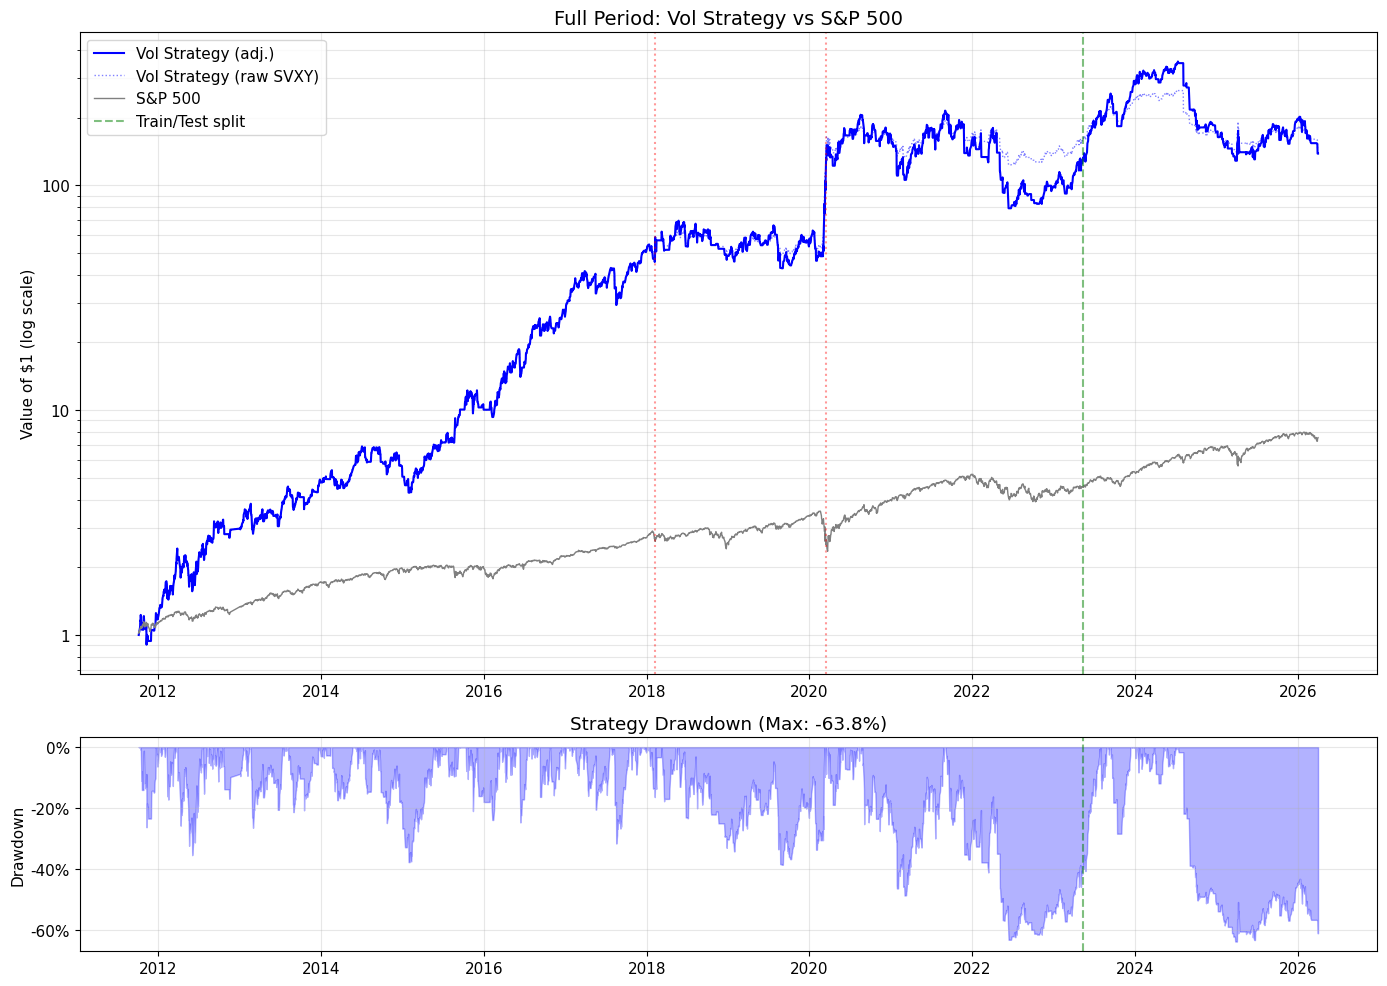


=== Full Period Stats ===
  Terminal ($1)       : 138.32
  CAGR                : 41.0%
  Vol (ann.)          : 52.4%
  Sharpe              : 0.92
  Sortino             : 0.95
  Max DD              : -63.8%
  Trades              : 543
  Days Short          : 2600
  Days Long           : 68
  Days Cash           : 950
  Period              : 2011-10-05 to 2026-04-02


In [19]:
full_start = etf_data.index.min().strftime('%Y-%m-%d')
full_end = etf_data.index.max().strftime('%Y-%m-%d')

bt_full, stats_full = backtest(data, sig_opt, 'Full', start=full_start, end=full_end)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[3, 1])

ax = axes[0]
ax.plot(bt_full.index, bt_full['etf_equity'], 'b-', lw=1.5, label='Vol Strategy (adj.)')
ax.plot(bt_full.index, bt_full['etf_equity_raw'], 'b:', lw=1, alpha=0.5, label='Vol Strategy (raw SVXY)')
ax.plot(bt_full.index, bt_full['spy_equity'], color='gray', lw=1, label='S&P 500')
ax.axvline(train_end, color='green', ls='--', alpha=0.5, label='Train/Test split')
for dt, lbl in [('2018-02-05', 'Volmageddon'), ('2020-03-16', 'COVID')]:
    evt = pd.Timestamp(dt)
    if evt >= bt_full.index.min():
        ax.axvline(evt, color='red', ls=':', alpha=0.4)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0f}'))
ax.set_title('Full Period: Vol Strategy vs S&P 500', fontsize=14)
ax.set_ylabel('Value of $1 (log scale)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')

ax2 = axes[1]
eq = bt_full['etf_equity']
dd = (eq / eq.cummax()) - 1
ax2.fill_between(dd.index, dd.values, 0, color='blue', alpha=0.3)
ax2.axvline(train_end, color='green', ls='--', alpha=0.5)
ax2.set_ylabel('Drawdown')
ax2.set_title(f'Strategy Drawdown (Max: {dd.min():.1%})')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n=== Full Period Stats ===')
for k, v in stats_full.items():
    print(f'  {k:20s}: {v}')

## 15. Portfolio: S&P 500 + Vol Strategy

Blend with constant daily rebalancing. Scan 0–50% vol strategy weight.

=== Optimal Portfolio Weights ===

Max Sharpe: 24% Vol + 76% SPY
  Sharpe=1.17, CAGR=23.8%, Max DD=-31.1%

Min Drawdown: 6% Vol + 94% SPY
  Sharpe=1.03, CAGR=17.4%, Max DD=-26.0%


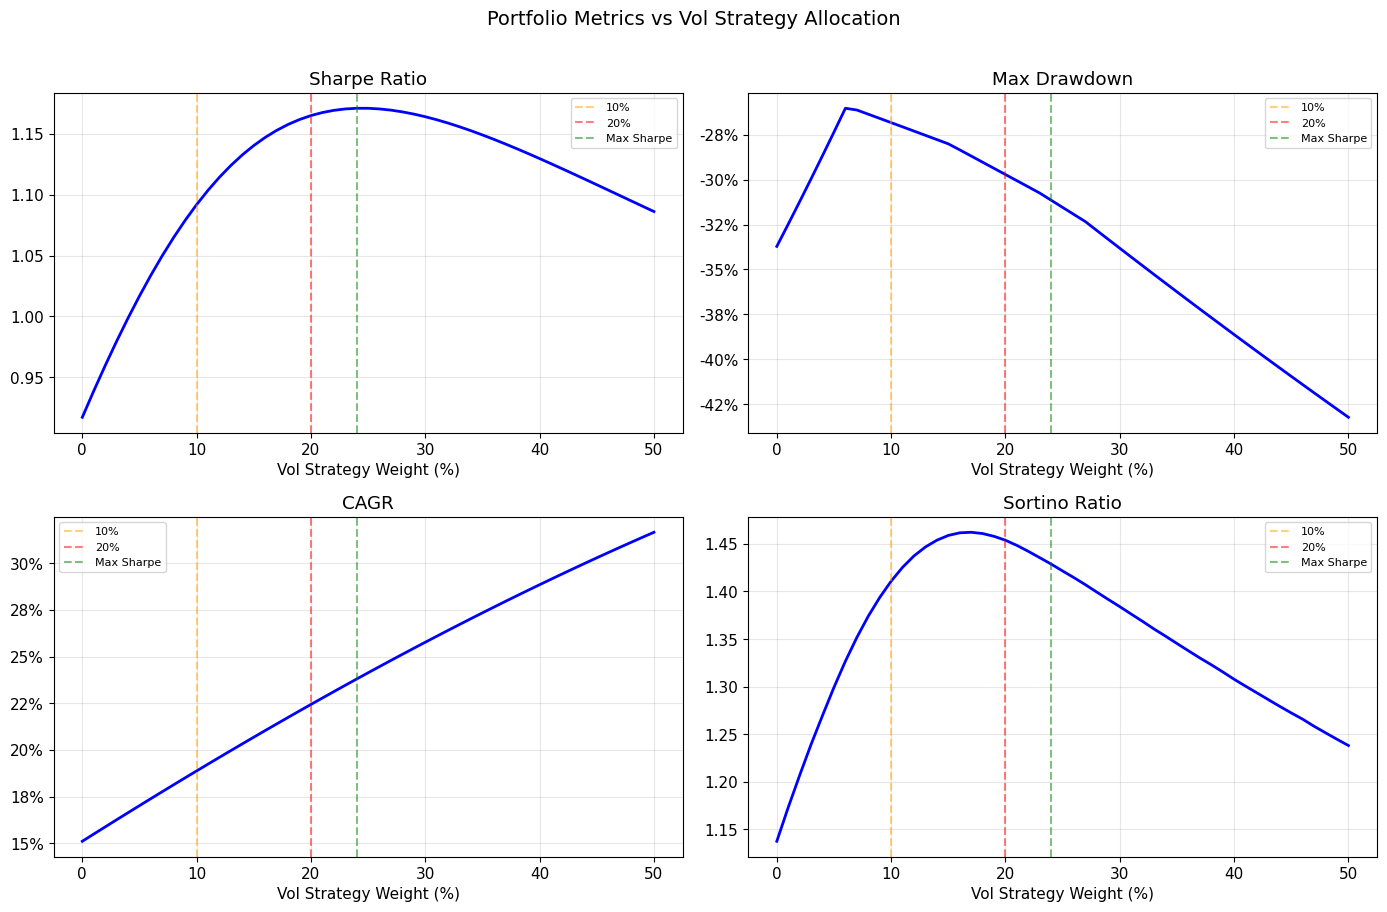

In [20]:
port_data = bt_full[['etf_ret', 'SPY_ret']].dropna().copy()

weights = np.arange(0.0, 0.51, 0.01)
port_results = []

for w_vol in weights:
    w_spy = 1 - w_vol
    port_ret = w_vol * port_data['etf_ret'] + w_spy * port_data['SPY_ret']
    port_eq = (1 + port_ret).cumprod()
    n_yrs = len(port_ret) / 252
    terminal = port_eq.iloc[-1]
    cagr = terminal ** (1/n_yrs) - 1
    vol = port_ret.std() * np.sqrt(252)
    sharpe = (port_ret.mean() * 252) / vol if vol > 0 else 0
    dd = (port_eq / port_eq.cummax() - 1).min()
    semi = port_ret[port_ret < 0].std() * np.sqrt(252)
    sortino = (port_ret.mean() * 252) / semi if semi > 0 else 0
    port_results.append({
        'w_vol': w_vol, 'w_spy': w_spy,
        'cagr': cagr, 'vol': vol, 'sharpe': sharpe,
        'sortino': sortino, 'max_dd': dd, 'terminal': terminal,
    })

port_df = pd.DataFrame(port_results)
best_sharpe = port_df.loc[port_df['sharpe'].idxmax()]
best_dd = port_df.loc[port_df['max_dd'].idxmax()]

print('=== Optimal Portfolio Weights ===')
print(f'\nMax Sharpe: {best_sharpe["w_vol"]:.0%} Vol + {best_sharpe["w_spy"]:.0%} SPY')
print(f'  Sharpe={best_sharpe["sharpe"]:.2f}, CAGR={best_sharpe["cagr"]:.1%}, '
      f'Max DD={best_sharpe["max_dd"]:.1%}')
print(f'\nMin Drawdown: {best_dd["w_vol"]:.0%} Vol + {best_dd["w_spy"]:.0%} SPY')
print(f'  Sharpe={best_dd["sharpe"]:.2f}, CAGR={best_dd["cagr"]:.1%}, '
      f'Max DD={best_dd["max_dd"]:.1%}')

# ── Metrics vs weight ──
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, metric, title in [
    (axes[0,0], 'sharpe', 'Sharpe Ratio'),
    (axes[0,1], 'max_dd', 'Max Drawdown'),
    (axes[1,0], 'cagr', 'CAGR'),
    (axes[1,1], 'sortino', 'Sortino Ratio'),
]:
    ax.plot(port_df['w_vol'] * 100, port_df[metric], 'b-', lw=2)
    ax.set_xlabel('Vol Strategy Weight (%)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.axvline(10, color='orange', ls='--', alpha=0.5, label='10%')
    ax.axvline(20, color='red', ls='--', alpha=0.5, label='20%')
    ax.axvline(best_sharpe['w_vol'] * 100, color='green', ls='--', alpha=0.5, label='Max Sharpe')
    if metric in ['max_dd', 'cagr']:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.legend(fontsize=8)

plt.suptitle('Portfolio Metrics vs Vol Strategy Allocation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 16. Portfolio Equity Curves

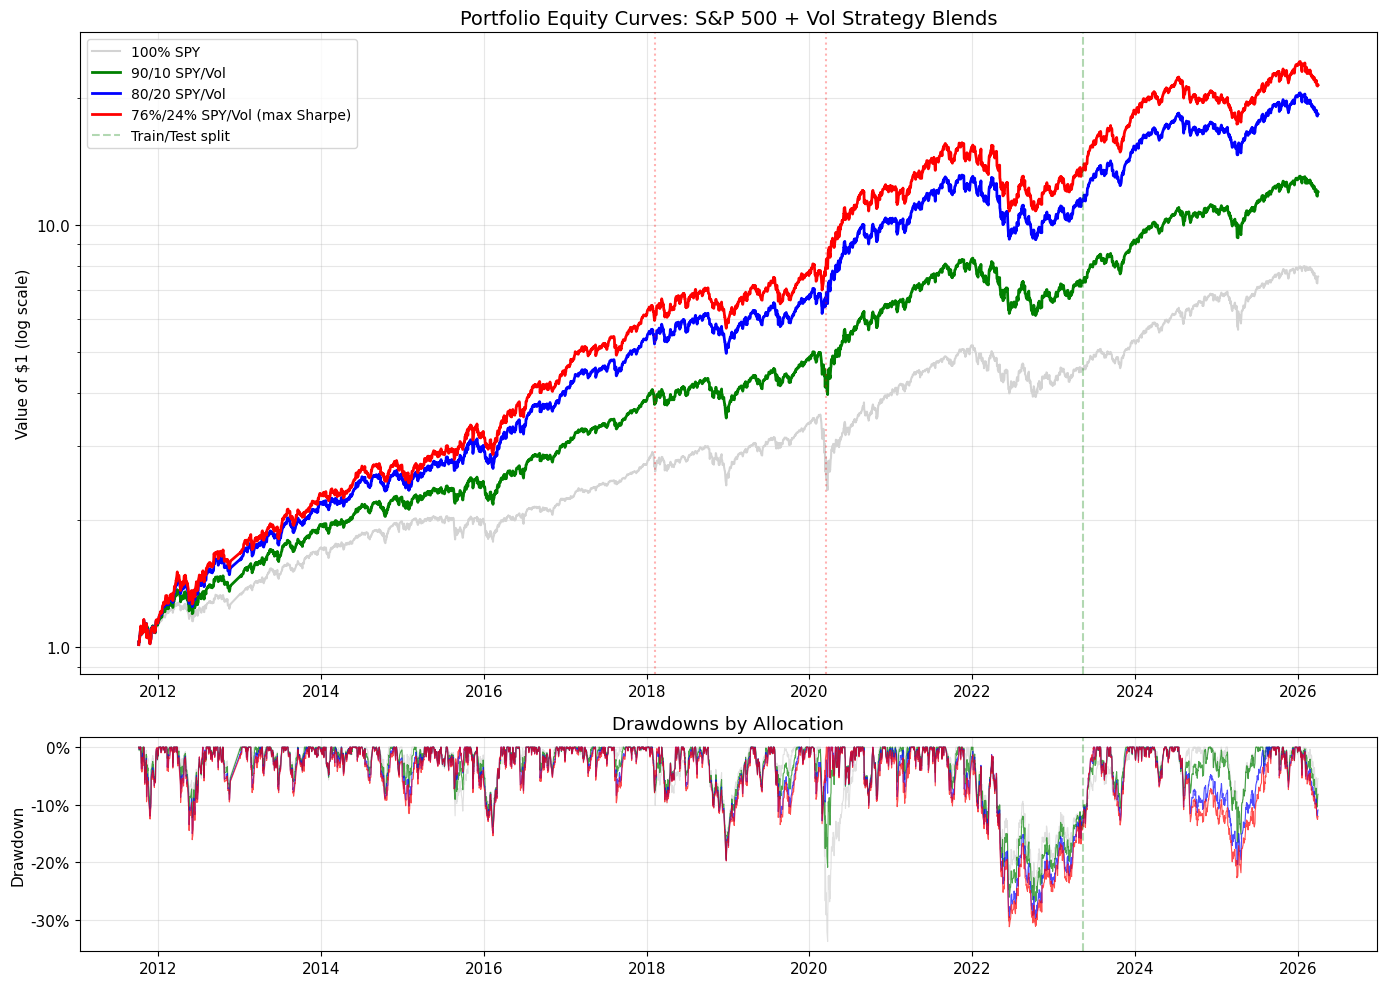

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[3, 1])

allocations = [
    (0.00, '100% SPY', 'lightgray'),
    (0.10, '90/10 SPY/Vol', 'green'),
    (0.20, '80/20 SPY/Vol', 'blue'),
    (best_sharpe['w_vol'],
     f'{best_sharpe["w_spy"]:.0%}/{best_sharpe["w_vol"]:.0%} SPY/Vol (max Sharpe)', 'red'),
]

ax = axes[0]
ax2 = axes[1]

for w_vol, label, color in allocations:
    port_ret = w_vol * port_data['etf_ret'] + (1 - w_vol) * port_data['SPY_ret']
    port_eq = (1 + port_ret).cumprod()
    ax.plot(port_eq.index, port_eq, color=color, lw=2 if w_vol > 0 else 1.5, label=label)
    dd = (port_eq / port_eq.cummax()) - 1
    ax2.plot(dd.index, dd, color=color, lw=0.8, alpha=0.7)

ax.axvline(train_end, color='green', ls='--', alpha=0.3, label='Train/Test split')
for dt, lbl in [('2018-02-05', 'Volmageddon'), ('2020-03-16', 'COVID')]:
    evt = pd.Timestamp(dt)
    if evt >= port_data.index.min():
        ax.axvline(evt, color='red', ls=':', alpha=0.3)

ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.set_title('Portfolio Equity Curves: S&P 500 + Vol Strategy Blends', fontsize=14)
ax.set_ylabel('Value of $1 (log scale)')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, which='both')

ax2.axvline(train_end, color='green', ls='--', alpha=0.3)
ax2.set_ylabel('Drawdown')
ax2.set_title('Drawdowns by Allocation')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 17. Summary Table — Key Allocations

In [22]:
summary_rows = []
for w_vol, label in [(0.0, '100% SPY'), (0.05, '95/5'), (0.10, '90/10'),
                      (0.15, '85/15'), (0.20, '80/20'),
                      (best_sharpe['w_vol'],
                       f'Max Sharpe ({best_sharpe["w_spy"]:.0%}/{best_sharpe["w_vol"]:.0%})')]:
    row = port_df.iloc[(port_df['w_vol'] - w_vol).abs().idxmin()]
    summary_rows.append({
        'Allocation': label,
        'Vol Wt': f'{row["w_vol"]:.0%}',
        'SPY Wt': f'{row["w_spy"]:.0%}',
        'CAGR': f'{row["cagr"]:.1%}',
        'Vol': f'{row["vol"]:.1%}',
        'Sharpe': f'{row["sharpe"]:.2f}',
        'Sortino': f'{row["sortino"]:.2f}',
        'Max DD': f'{row["max_dd"]:.1%}',
        'Terminal': f'${row["terminal"]:.2f}',
    })

display(pd.DataFrame(summary_rows).set_index('Allocation'))

,Vol Wt,SPY Wt,CAGR,Vol,Sharpe,Sortino,Max DD,Terminal
Allocation,,,,,,,,
100% SPY,0%,100%,15.1%,16.9%,0.92,1.14,-33.7%,$7.54
95/5,5%,95%,17.0%,16.9%,1.02,1.30,-27.3%,$9.55
90/10,10%,90%,18.9%,17.2%,1.09,1.41,-26.8%,$11.98
85/15,15%,85%,20.7%,17.9%,1.14,1.46,-28.0%,$14.87
80/20,20%,80%,22.4%,18.9%,1.16,1.45,-29.7%,$18.29
Max Sharpe (76%/24%),24%,76%,23.8%,20.0%,1.17,1.43,-31.1%,$21.44


---
# Part III: Robustness & Live-Readiness

## 18. Backtest with Realistic Trading Costs (Interactive Brokers)

**IB Tiered pricing (US ETFs):**
- Commission: $0.0035/share, min $0.35, max 1% of trade value
- Bid-ask spread: ~3 bps normal, ~8 bps when VIX > 25

**Note (v3):** This backtest lets allocations drift naturally after each day's P&L
(no intraday rebalancing to target weights). This is realistic for a retail investor
who rebalances monthly or quarterly, not daily.

In [23]:
PORTFOLIO_EUR  = 20_000
EUR_USD        = 1.075
PORTFOLIO_USD  = PORTFOLIO_EUR * EUR_USD

COMMISSION_PER_SHARE = 0.0035
MIN_COMMISSION       = 0.35
MAX_COMMISSION_PCT   = 0.01

HALF_SPREAD_NORMAL = 0.0003  # 3 bps
HALF_SPREAD_STRESS = 0.0008  # 8 bps
VIX_STRESS_LEVEL   = 25

print(f'Portfolio: €{PORTFOLIO_EUR:,.0f} = ${PORTFOLIO_USD:,.0f}')

Portfolio: €20,000 = $21,500


In [24]:
def backtest_with_costs(data, signal, portfolio_usd, w_vol=0.30, w_spy=0.70,
                         start=None, end=None, use_adj_svxy=True):
    """
    Backtest blended portfolio (SPY + vol strategy) with IB trading costs.
    The vol portion switches between SVXY/VIXY/CASH.
    Allocations drift naturally (no daily rebalancing to target weights).
    """
    df = data.loc[start:end].copy() if start else data.copy()
    sig = signal.reindex(df.index).fillna('CASH')
    df['signal'] = sig
    df = df.dropna(subset=['SVXY', 'VIXY', 'SPY']).copy()
    if len(df) == 0:
        return pd.DataFrame(), {}

    svxy_col = 'SVXY_ret_adj' if use_adj_svxy else 'SVXY_ret'

    # Compute vol strategy return per row
    df['vol_ret'] = 0.0
    df.loc[df['signal'] == 'SVXY', 'vol_ret'] = df.loc[df['signal'] == 'SVXY', svxy_col]
    df.loc[df['signal'] == 'VIXY', 'vol_ret'] = df.loc[df['signal'] == 'VIXY', 'VIXY_ret']

    vol_alloc = portfolio_usd * w_vol
    spy_alloc = portfolio_usd * w_spy

    equity = [portfolio_usd]
    total_costs = 0.0
    n_trades = 0
    cost_list = [0.0]
    prev_signal = 'CASH'

    for i in range(1, len(df)):
        row = df.iloc[i]
        prev_row = df.iloc[i-1]
        cur_signal = df['signal'].iloc[i]

        spy_pnl = spy_alloc * (row['SPY_ret'] if not np.isnan(row['SPY_ret']) else 0.0)
        vol_pnl = vol_alloc * (row['vol_ret'] if not np.isnan(row['vol_ret']) else 0.0)

        # Trading costs on signal change
        trade_cost = 0.0
        if cur_signal != prev_signal:
            n_trades += 1
            vix_now = row['VIX'] if not np.isnan(row['VIX']) else 15
            half_spread = HALF_SPREAD_STRESS if vix_now > VIX_STRESS_LEVEL else HALF_SPREAD_NORMAL

            # Exit cost
            if prev_signal != 'CASH':
                exit_px = prev_row['SVXY'] if prev_signal == 'SVXY' else prev_row['VIXY']
                if exit_px > 0 and not np.isnan(exit_px):
                    n_sh = vol_alloc / exit_px
                    comm = max(MIN_COMMISSION, min(n_sh * COMMISSION_PER_SHARE,
                                                   vol_alloc * MAX_COMMISSION_PCT))
                    trade_cost += comm + vol_alloc * half_spread

            # Entry cost
            if cur_signal != 'CASH':
                entry_px = row['SVXY'] if cur_signal == 'SVXY' else row['VIXY']
                if entry_px > 0 and not np.isnan(entry_px):
                    n_sh = vol_alloc / entry_px
                    comm = max(MIN_COMMISSION, min(n_sh * COMMISSION_PER_SHARE,
                                                   vol_alloc * MAX_COMMISSION_PCT))
                    trade_cost += comm + vol_alloc * half_spread

        total_costs += trade_cost
        cost_list.append(trade_cost)

        spy_alloc += spy_pnl
        vol_alloc = max(vol_alloc + vol_pnl - trade_cost, 0)
        equity.append(spy_alloc + vol_alloc)
        prev_signal = cur_signal

    df = df.iloc[:len(equity)].copy()
    df['equity'] = equity
    df['cost'] = cost_list
    df['equity_norm'] = df['equity'] / df['equity'].iloc[0]

    # No-cost comparison
    df['nocost_vol_ret'] = df['vol_ret']
    nocost_blend = w_vol * df['vol_ret'] + w_spy * df['SPY_ret']
    df['nocost_equity'] = (1 + nocost_blend).cumprod()
    df['spy_only_eq'] = (1 + df['SPY_ret']).cumprod()

    n_yrs = len(df) / 252
    terminal = df['equity_norm'].iloc[-1]
    cagr = terminal ** (1/n_yrs) - 1 if n_yrs > 0 else 0
    blend_ret = df['equity'].pct_change().dropna()
    vol = blend_ret.std() * np.sqrt(252)
    sharpe = (blend_ret.mean() * 252) / vol if vol > 0 else 0
    dd = (df['equity_norm'] / df['equity_norm'].cummax() - 1).min()

    stats = {
        'Terminal ($1)': f'{terminal:.2f}',
        'CAGR': f'{cagr:.1%}', 'Vol (ann.)': f'{vol:.1%}',
        'Sharpe': f'{sharpe:.2f}', 'Max DD': f'{dd:.1%}',
        'Total costs': f'${total_costs:,.2f}',
        'Trades': n_trades,
        'Period': f"{df.index.min().date()} to {df.index.max().date()}",
    }
    return df, stats

print('Cost engine ready.')

Cost engine ready.


### 18a. Full Period: 70/30 SPY/Vol with Trading Costs

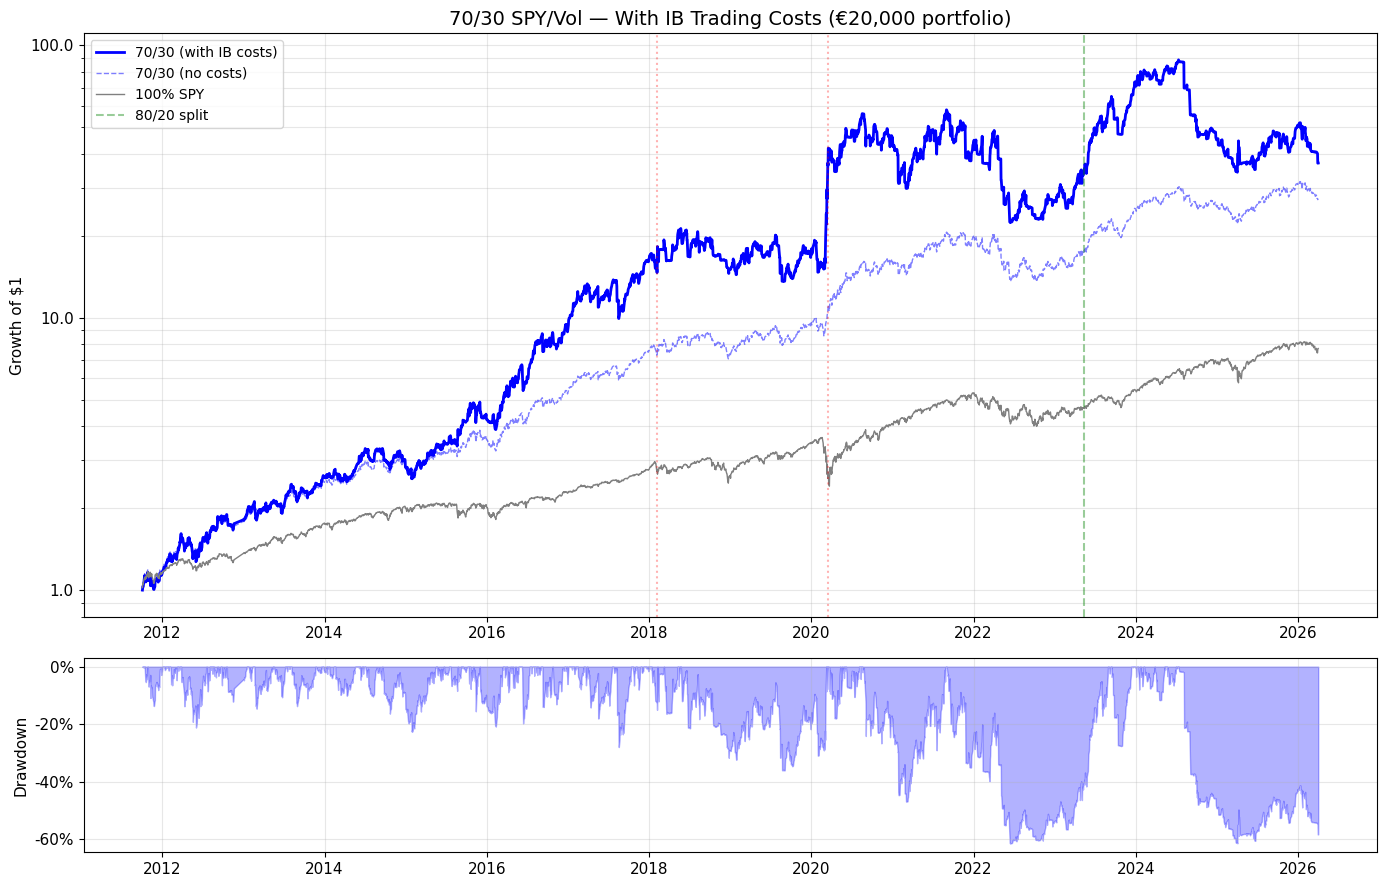


=== 70/30 Portfolio with IB Costs ===
  Terminal ($1)       : 36.97
  CAGR                : 28.6%
  Vol (ann.)          : 43.5%
  Sharpe              : 0.80
  Max DD              : -61.4%
  Total costs         : $140,751.11
  Trades              : 542
  Period              : 2011-10-04 to 2026-04-02
  Cost drag:          35.39%


In [25]:
full_start = etf_data.index.min().strftime('%Y-%m-%d')
full_end = etf_data.index.max().strftime('%Y-%m-%d')

bt_cost, stats_cost = backtest_with_costs(
    data, sig_opt, PORTFOLIO_USD, w_vol=0.30, w_spy=0.70,
    start=full_start, end=full_end
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[3, 1])

ax = axes[0]
ax.plot(bt_cost.index, bt_cost['equity_norm'], 'b-', lw=2, label='70/30 (with IB costs)')
ax.plot(bt_cost.index, bt_cost['nocost_equity'], 'b--', lw=1, alpha=0.5, label='70/30 (no costs)')
ax.plot(bt_cost.index, bt_cost['spy_only_eq'], color='gray', lw=1, label='100% SPY')
ax.axvline(train_end, color='green', ls='--', alpha=0.4, label='80/20 split')
for dt in ['2018-02-05', '2020-03-16']:
    evt = pd.Timestamp(dt)
    if evt >= bt_cost.index.min():
        ax.axvline(evt, color='red', ls=':', alpha=0.3)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.set_title(f'70/30 SPY/Vol — With IB Trading Costs (€{PORTFOLIO_EUR:,.0f} portfolio)', fontsize=14)
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')

ax2 = axes[1]
eq = bt_cost['equity_norm']
dd = (eq / eq.cummax()) - 1
ax2.fill_between(dd.index, dd.values, 0, color='blue', alpha=0.3)
ax2.set_ylabel('Drawdown')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n=== 70/30 Portfolio with IB Costs ===')
for k, v in stats_cost.items():
    print(f'  {k:20s}: {v}')
print(f'  Cost drag:          {(bt_cost["equity_norm"].iloc[-1] / bt_cost["nocost_equity"].iloc[-1] - 1):.2%}')

## 19. Robustness Check 1: Fixed 2016 Split (Volmageddon & COVID OOS)

Complement to the main 80/20 split: train until end-2016, test 2017+.

Fixed split optimised: ST=0.0300, LT=-0.5000 (train Sharpe=1.55)


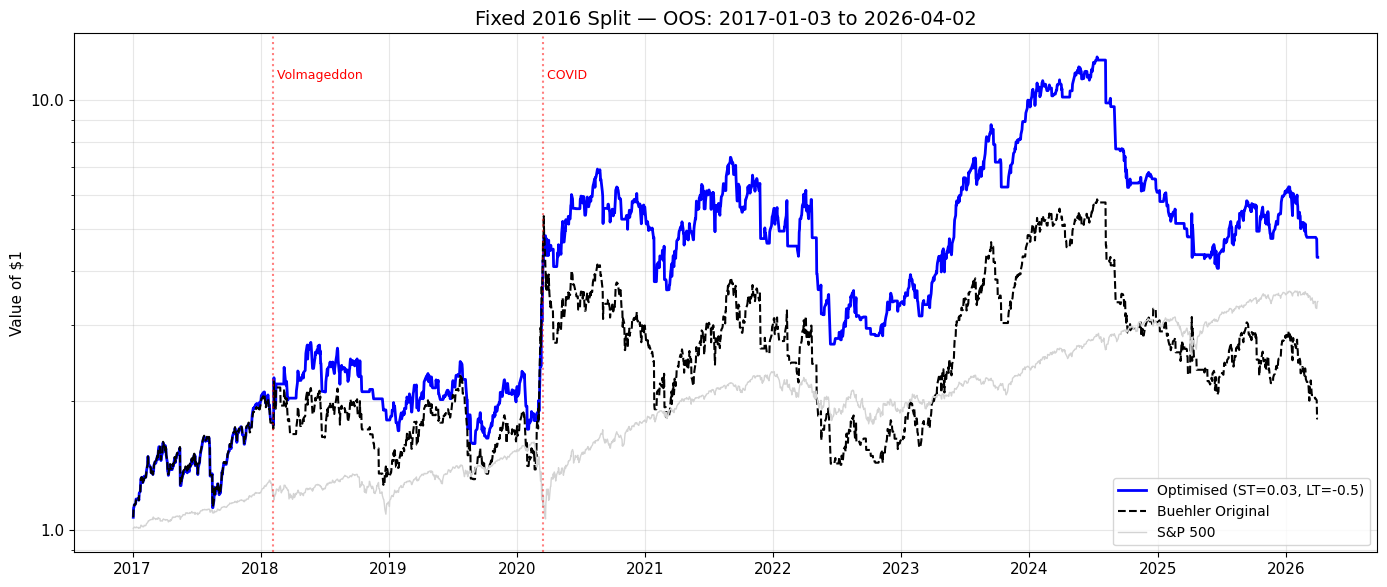

,Terminal ($1),CAGR,Vol (ann.),Sharpe,Sortino,Max DD,Trades,Days Short,Days Long,Days Cash,Period
Optimised,4.31,17.1%,52.9%,0.57,0.55,-67.7%,391,1579,47,700,2017-01-03 to 2026-04-02
Buehler,1.82,6.7%,56.8%,0.40,0.41,-73.6%,411,1649,107,570,2017-01-03 to 2026-04-02


In [26]:
FIXED_TRAIN_END  = '2016-12-30'
FIXED_TEST_START = '2017-01-03'

# Optimise on fixed train set
best_fixed_sharpe = -999
best_fixed_st, best_fixed_lt = BUEHLER_SHORT, BUEHLER_LONG
for st in np.arange(0.005, 0.10, 0.005):
    for lt in np.arange(-0.50, -0.02, 0.02):
        sig_tmp = generate_signals(data, st, lt)
        bt_tmp, s_tmp = backtest(data, sig_tmp, '', start=full_start, end=FIXED_TRAIN_END)
        if len(bt_tmp) == 0: continue
        n_tr = int(s_tmp['Trades'])
        s = float(s_tmp['Sharpe']) if n_tr >= MIN_TRADES else -999
        if s > best_fixed_sharpe:
            best_fixed_sharpe = s
            best_fixed_st, best_fixed_lt = round(st, 4), round(lt, 4)

print(f'Fixed split optimised: ST={best_fixed_st:.4f}, LT={best_fixed_lt:.4f} (train Sharpe={best_fixed_sharpe:.2f})')

# Test
sig_fixed = generate_signals(data, best_fixed_st, best_fixed_lt)
bt_fixed, stats_fixed = backtest(data, sig_fixed, 'Fixed 2016', start=FIXED_TEST_START, end=full_end)
bt_fixed_b, stats_fixed_b = backtest(data, sig_buehler, 'Buehler', start=FIXED_TEST_START, end=full_end)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(bt_fixed.index, bt_fixed['etf_equity'], 'b-', lw=2,
        label=f'Optimised (ST={best_fixed_st}, LT={best_fixed_lt})')
ax.plot(bt_fixed_b.index, bt_fixed_b['etf_equity'], 'k--', lw=1.5, label='Buehler Original')
ax.plot(bt_fixed.index, bt_fixed['spy_equity'], color='lightgray', lw=1, label='S&P 500')
for dt, lbl in [('2018-02-05', 'Volmageddon'), ('2020-03-16', 'COVID')]:
    evt = pd.Timestamp(dt)
    if evt >= bt_fixed.index.min() and evt <= bt_fixed.index.max():
        ax.axvline(evt, color='red', ls=':', alpha=0.5)
        ax.text(evt, ax.get_ylim()[1]*0.85, f' {lbl}', fontsize=9, color='red')
ax.set_title(f'Fixed 2016 Split — OOS: {FIXED_TEST_START} to {full_end}', fontsize=14)
ax.set_ylabel('Value of $1')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

comp_fixed = pd.DataFrame({'Optimised': stats_fixed, 'Buehler': stats_fixed_b}).T
display(comp_fixed)

## 20. Robustness Check 2: Walk-Forward Optimisation

Rolling 3-year train window, re-optimise yearly.

In [27]:
def walk_forward(data, etf_start, etf_end, train_years=3, step_months=12):
    results = []
    opt_dates = pd.date_range(
        start=pd.Timestamp(etf_start) + pd.DateOffset(years=train_years),
        end=etf_end, freq=f'{step_months}MS'
    )
    for opt_date in opt_dates:
        tr_s = (opt_date - pd.DateOffset(years=train_years)).strftime('%Y-%m-%d')
        tr_e = (opt_date - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
        te_s = opt_date.strftime('%Y-%m-%d')
        te_e = (opt_date + pd.DateOffset(months=step_months) - pd.Timedelta(days=1)).strftime('%Y-%m-%d')

        best_s, b_st, b_lt = -999, 0.02, -0.24
        for st in np.arange(0.005, 0.08, 0.01):
            for lt in np.arange(-0.50, -0.04, 0.04):
                sig_tmp = generate_signals(data, st, lt)
                bt_tmp, s_tmp = backtest(data, sig_tmp, '', start=tr_s, end=tr_e)
                if len(bt_tmp) == 0: continue
                n_tr = int(s_tmp['Trades'])
                s = float(s_tmp['Sharpe']) if n_tr >= 10 else -999
                if s > best_s:
                    best_s, b_st, b_lt = s, round(st, 4), round(lt, 4)

        results.append({
            'opt_date': opt_date, 'train': f'{tr_s} to {tr_e}',
            'test': f'{te_s} to {te_e}',
            'opt_short': b_st, 'opt_long': b_lt, 'train_sharpe': best_s,
        })
    return pd.DataFrame(results)

wf_results = walk_forward(data, full_start, full_end)
print('=== Walk-Forward Windows ===')
print(wf_results[['opt_date', 'opt_short', 'opt_long', 'train_sharpe']].to_string(index=False))

=== Walk-Forward Windows ===
  opt_date  opt_short  opt_long  train_sharpe
2014-11-01      0.025     -0.50          1.51
2015-11-01      0.065     -0.50          1.30
2016-11-01      0.035     -0.38          1.36
2017-11-01      0.045     -0.50          1.53
2018-11-01      0.055     -0.50          1.31
2019-11-01      0.075     -0.50          0.90
2020-11-01      0.075     -0.34          1.30
2021-11-01      0.075     -0.34          1.12
2022-11-01      0.015     -0.34          0.70
2023-11-01      0.025     -0.50          0.49
2024-11-01      0.035     -0.50          0.46
2025-11-01      0.035     -0.34          0.93


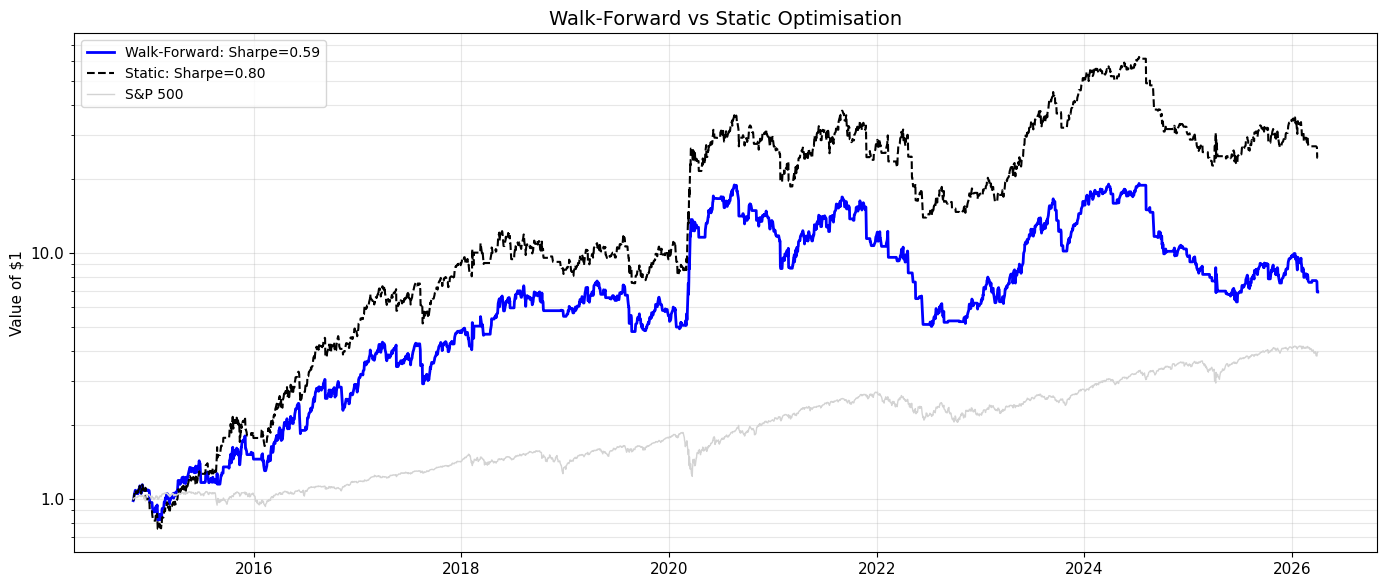

In [28]:
# Stitch together OOS signals
wf_signal = pd.Series('CASH', index=data.index)
for _, row in wf_results.iterrows():
    ts, te = row['test'].split(' to ')
    sig_tmp = generate_signals(data, row['opt_short'], row['opt_long'])
    mask = (data.index >= ts) & (data.index <= te)
    wf_signal[mask] = sig_tmp[mask]

wf_start = wf_results.iloc[0]['test'].split(' to ')[0]
bt_wf, stats_wf = backtest(data, wf_signal, 'Walk-Forward', start=wf_start, end=full_end)
bt_static, stats_static = backtest(data, sig_opt, 'Static Opt', start=wf_start, end=full_end)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(bt_wf.index, bt_wf['etf_equity'], 'b-', lw=2, label=f'Walk-Forward: Sharpe={stats_wf["Sharpe"]}')
ax.plot(bt_static.index, bt_static['etf_equity'], 'k--', lw=1.5, label=f'Static: Sharpe={stats_static["Sharpe"]}')
ax.plot(bt_wf.index, bt_wf['spy_equity'], color='lightgray', lw=1, label='S&P 500')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.set_title('Walk-Forward vs Static Optimisation', fontsize=14)
ax.set_ylabel('Value of $1')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 21. Robustness Check 3: Subperiod Analysis

Annual performance of the 70/30 blend vs pure SPY.

In [29]:
blend_ret = 0.30 * bt_full['etf_ret'] + 0.70 * bt_full['SPY_ret']

annual_stats = []
for yr in sorted(bt_full.index.year.unique()):
    br = blend_ret[bt_full.index.year == yr].dropna()
    sr = bt_full.loc[bt_full.index.year == yr, 'SPY_ret'].dropna()
    if len(br) < 20: continue

    b_eq = (1 + br).cumprod()
    s_eq = (1 + sr).cumprod()
    b_ret = b_eq.iloc[-1] - 1
    s_ret = s_eq.iloc[-1] - 1
    b_vol = br.std() * np.sqrt(252)
    b_sharpe = (br.mean() * 252) / b_vol if b_vol > 0 else 0
    b_dd = (b_eq / b_eq.cummax() - 1).min()
    s_dd = (s_eq / s_eq.cummax() - 1).min()

    in_train = pd.Timestamp(f'{yr}-06-30') <= train_end

    annual_stats.append({
        'Year': yr, 'Sample': 'TRAIN' if in_train else 'TEST',
        '70/30 Ret': f'{b_ret:.1%}', 'SPY Ret': f'{s_ret:.1%}',
        '70/30 Sharpe': f'{b_sharpe:.2f}',
        '70/30 MaxDD': f'{b_dd:.1%}', 'SPY MaxDD': f'{s_dd:.1%}',
        'Beats SPY': '✅' if b_ret > s_ret else '❌',
    })

annual_df = pd.DataFrame(annual_stats).set_index('Year')
display(annual_df)

oos_years = annual_df[annual_df['Sample'] == 'TEST']
n_win = (oos_years['Beats SPY'] == '✅').sum()
print(f'\nOOS years 70/30 beats SPY: {n_win}/{len(oos_years)}')

,Sample,70/30 Ret,SPY Ret,70/30 Sharpe,70/30 MaxDD,SPY MaxDD,Beats SPY
Year,,,,,,,
2011,TRAIN,15.3%,12.4%,1.78,-13.2%,-9.6%,✅
2012,TRAIN,46.8%,12.6%,1.76,-17.7%,-9.7%,✅
2013,TRAIN,45.8%,36.3%,2.10,-9.6%,-5.6%,✅
2014,TRAIN,12.6%,13.5%,0.81,-10.5%,-7.3%,❌
2015,TRAIN,26.8%,1.2%,1.23,-8.9%,-11.9%,✅
2016,TRAIN,46.9%,12.0%,1.93,-8.9%,-9.2%,✅
2017,TRAIN,42.5%,21.7%,2.20,-11.5%,-2.6%,✅
2018,TRAIN,-1.6%,-4.6%,0.02,-19.9%,-19.3%,✅
2019,TRAIN,27.9%,31.2%,1.38,-15.3%,-6.6%,❌



OOS years 70/30 beats SPY: 2/4


## 22. Robustness Check 4: Execution Delay Sensitivity

What if you can't trade next-day open? Test +1 and +2 day additional delays.

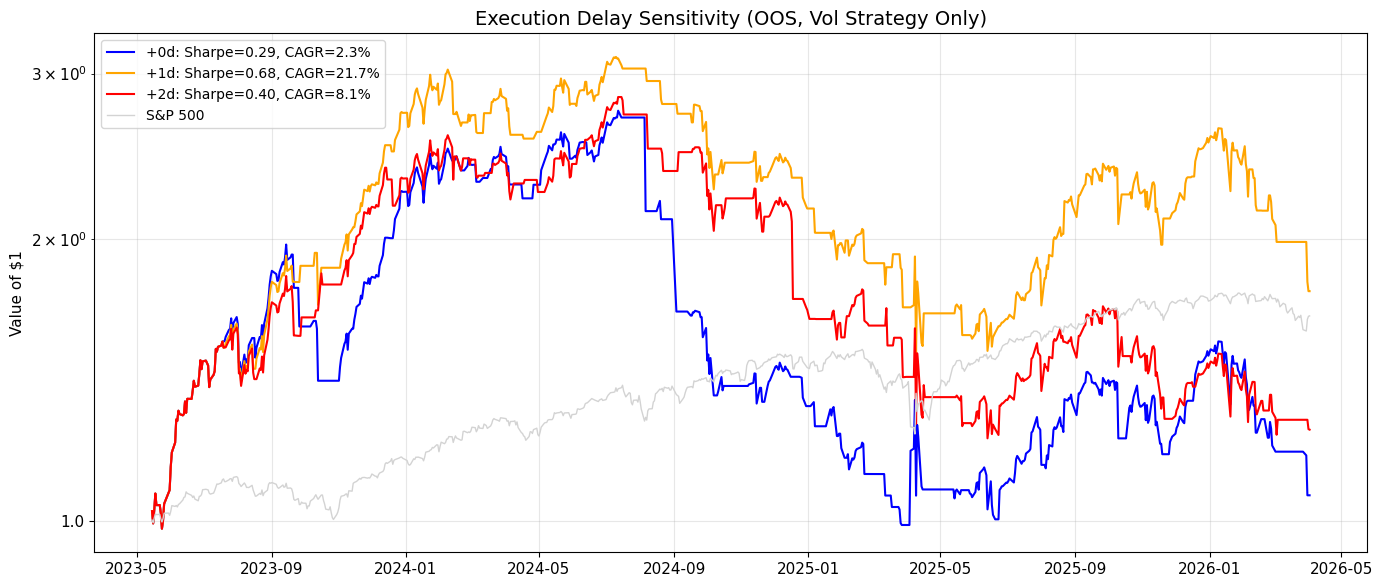

,Terminal ($1),CAGR,Vol (ann.),Sharpe,Sortino,Max DD,Trades,Days Short,Days Long,Days Cash,Period
Delay,,,,,,,,,,,
+0d,1.07,2.3%,46.4%,0.29,0.25,-63.8%,122,464,16,245,2023-05-15 to 2026-04-02
+1d,1.76,21.7%,42.9%,0.68,0.64,-51.5%,122,465,16,244,2023-05-15 to 2026-04-02
+2d,1.25,8.1%,44.0%,0.40,0.38,-56.7%,121,466,16,243,2023-05-15 to 2026-04-02


In [30]:
def signals_delayed(data, short_thresh, long_thresh, delay=0):
    prev_roll = data['daily_roll'].shift(1 + delay)
    signal = pd.Series('CASH', index=data.index)
    signal[prev_roll >= short_thresh] = 'SVXY'
    signal[prev_roll <= long_thresh]  = 'VIXY'
    return signal

delay_results = []
fig, ax = plt.subplots(figsize=(14, 6))

for delay, color in [(0, 'blue'), (1, 'orange'), (2, 'red')]:
    sig_d = signals_delayed(data, OPT_SHORT, OPT_LONG, delay=delay)
    bt_d, stats_d = backtest(data, sig_d, f'+{delay}d', start=test_start.strftime('%Y-%m-%d'), end=full_end)
    if len(bt_d) > 0:
        ax.plot(bt_d.index, bt_d['etf_equity'], color=color, lw=1.5,
                label=f'+{delay}d: Sharpe={stats_d["Sharpe"]}, CAGR={stats_d["CAGR"]}')
        delay_results.append({'Delay': f'+{delay}d', **stats_d})

ax.plot(bt_d.index, bt_d['spy_equity'], color='lightgray', lw=1, label='S&P 500')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.set_title('Execution Delay Sensitivity (OOS, Vol Strategy Only)', fontsize=14)
ax.set_ylabel('Value of $1')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

display(pd.DataFrame(delay_results).set_index('Delay'))

## 23. Robustness Check 5: Parameter Neighbourhood Stability

Test all thresholds within ±30% of the optimum on OOS data.

Parameter neighbourhood (OOS): 130 combos
Sharpe: [0.14, 0.53], mean=0.30, std=0.09
% positive Sharpe: 100%


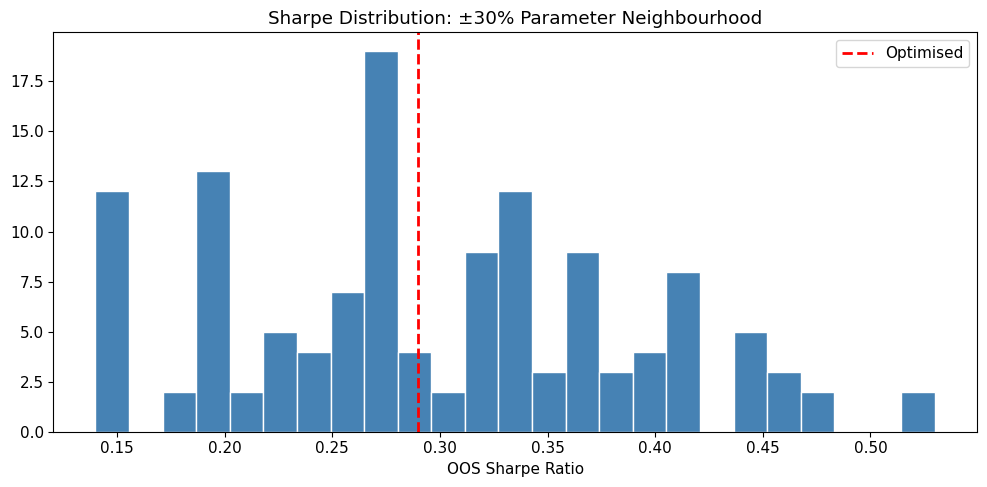

In [31]:
st_range = np.arange(OPT_SHORT * 0.7, OPT_SHORT * 1.3 + 0.001, 0.002)
lt_range = np.arange(OPT_LONG * 1.3, OPT_LONG * 0.7 + 0.001, 0.02)

neighbourhood = []
for st in st_range:
    for lt in lt_range:
        sig_n = generate_signals(data, st, lt)
        bt_n, stats_n = backtest(data, sig_n, '', start=test_start.strftime('%Y-%m-%d'), end=full_end)
        if len(bt_n) == 0: continue
        neighbourhood.append({
            'short': round(st, 4), 'long': round(lt, 3),
            'sharpe': float(stats_n['Sharpe']),
        })

nb_df = pd.DataFrame(neighbourhood)

print(f'Parameter neighbourhood (OOS): {len(nb_df)} combos')
print(f'Sharpe: [{nb_df["sharpe"].min():.2f}, {nb_df["sharpe"].max():.2f}], '
      f'mean={nb_df["sharpe"].mean():.2f}, std={nb_df["sharpe"].std():.2f}')
print(f'% positive Sharpe: {(nb_df["sharpe"] > 0).mean():.0%}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(nb_df['sharpe'], bins=25, color='steelblue', edgecolor='white')
ax.axvline(float(stats_opt['Sharpe']), color='red', ls='--', lw=2, label='Optimised')
ax.set_xlabel('OOS Sharpe Ratio')
ax.set_title('Sharpe Distribution: ±30% Parameter Neighbourhood')
ax.legend()
plt.tight_layout()
plt.show()

## 24. Robustness Check 6: Permutation Test (Random Signals)

1,000 random signal sequences with the same SVXY/VIXY/CASH proportions.

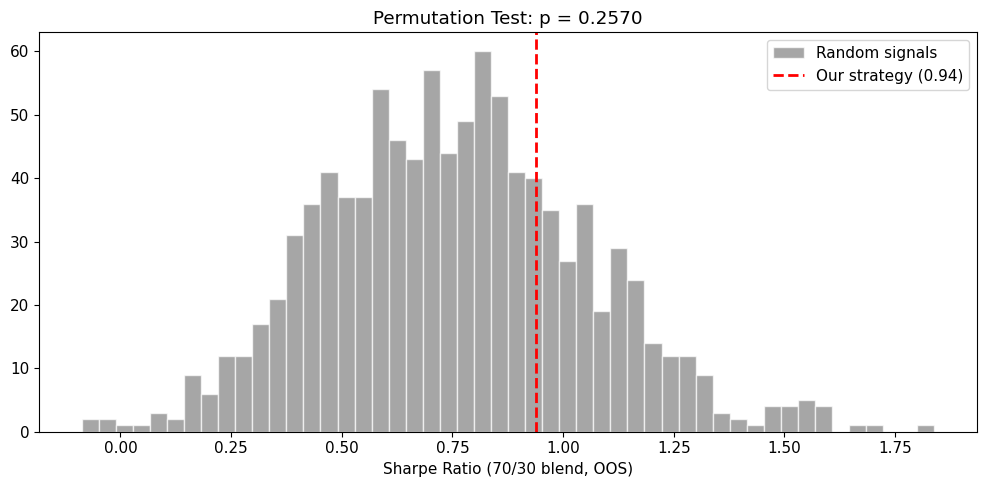

Strategy Sharpe: 0.939, Random mean: 0.755
p-value: 0.2570 → Not significant ❌


In [32]:
np.random.seed(42)
N_PERMS = 1000

oos_range = data.loc[test_start.strftime('%Y-%m-%d'):full_end].dropna(subset=['SVXY_ret','VIXY_ret']).copy()
oos_sig = sig_opt.reindex(oos_range.index)

n_svxy = (oos_sig == 'SVXY').sum()
n_vixy = (oos_sig == 'VIXY').sum()
n_cash = (oos_sig == 'CASH').sum()
total = len(oos_sig)
probs = [n_svxy/total, n_vixy/total, n_cash/total]

svxy_col = 'SVXY_ret_adj'  # v3: use adjusted returns

# Actual strategy OOS Sharpe (70/30 blend)
actual_vol_ret = np.zeros(total)
actual_vol_ret[oos_sig.values == 'SVXY'] = oos_range[svxy_col].values[oos_sig.values == 'SVXY']
actual_vol_ret[oos_sig.values == 'VIXY'] = oos_range['VIXY_ret'].values[oos_sig.values == 'VIXY']
actual_blend = 0.30 * actual_vol_ret + 0.70 * oos_range['SPY_ret'].values
actual_sharpe = (np.nanmean(actual_blend) * 252) / (np.nanstd(actual_blend) * np.sqrt(252))

random_sharpes = []
for _ in range(N_PERMS):
    rand_sig = np.random.choice(['SVXY', 'VIXY', 'CASH'], size=total, p=probs)
    rand_ret = np.zeros(total)
    rand_ret[rand_sig == 'SVXY'] = oos_range[svxy_col].values[rand_sig == 'SVXY']
    rand_ret[rand_sig == 'VIXY'] = oos_range['VIXY_ret'].values[rand_sig == 'VIXY']
    blend = 0.30 * rand_ret + 0.70 * oos_range['SPY_ret'].values
    vol = np.nanstd(blend) * np.sqrt(252)
    random_sharpes.append((np.nanmean(blend) * 252) / vol if vol > 0 else 0)

random_sharpes = np.array(random_sharpes)
pval = (random_sharpes >= actual_sharpe).mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(random_sharpes, bins=50, color='gray', edgecolor='white', alpha=0.7, label='Random signals')
ax.axvline(actual_sharpe, color='red', lw=2, ls='--', label=f'Our strategy ({actual_sharpe:.2f})')
ax.set_xlabel('Sharpe Ratio (70/30 blend, OOS)')
ax.set_title(f'Permutation Test: p = {pval:.4f}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'Strategy Sharpe: {actual_sharpe:.3f}, Random mean: {random_sharpes.mean():.3f}')
print(f'p-value: {pval:.4f} → {"Significant ✅" if pval < 0.05 else "Not significant ❌"}')

## 25. Robustness Scorecard

In [33]:
print('=' * 65)
print('ROBUSTNESS SCORECARD')
print('=' * 65)

cost_drag = bt_cost['equity_norm'].iloc[-1] / bt_cost['nocost_equity'].iloc[-1] - 1

checks = [
    ('Trading costs (IB €20k)',
     f'Drag: {cost_drag:.1%}',
     abs(cost_drag) < 0.15),
    ('Fixed 2016 split (Volmag+COVID OOS)',
     f'Sharpe={stats_fixed["Sharpe"]}',
     float(stats_fixed['Sharpe']) > 0),
    ('Walk-forward optimisation',
     f'Sharpe={stats_wf["Sharpe"]}',
     float(stats_wf['Sharpe']) > 0),
    ('Subperiod consistency',
     f'{n_win}/{len(oos_years)} OOS years beat SPY',
     n_win > len(oos_years) * 0.4),
    ('Execution delay (+1d)',
     f'Sharpe={delay_results[1]["Sharpe"] if len(delay_results) > 1 else "N/A"}',
     len(delay_results) > 1 and float(delay_results[1].get('Sharpe', '0')) > 0),
    ('Parameter neighbourhood (±30%)',
     f'{(nb_df["sharpe"] > 0).mean():.0%} positive Sharpe',
     (nb_df['sharpe'] > 0).mean() > 0.70),
    ('Permutation test (p<0.05)',
     f'p = {pval:.4f}',
     pval < 0.05),
]

for name, detail, passed in checks:
    print(f'  {"✅" if passed else "❌"} {name:40s} | {detail}')

n_passed = sum(1 for _,_,p in checks if p)
print(f'\nPassed: {n_passed}/{len(checks)}')
if n_passed >= 5:
    print('\n→ Strategy appears robust enough for live trading with appropriate position sizing.')
elif n_passed >= 3:
    print('\n→ Strategy shows promise but has weaknesses. Proceed with caution and smaller sizing.')
else:
    print('\n→ Strategy may be overfit. Reconsider before going live.')

ROBUSTNESS SCORECARD
  ❌ Trading costs (IB €20k)                  | Drag: 35.4%
  ✅ Fixed 2016 split (Volmag+COVID OOS)      | Sharpe=0.57
  ✅ Walk-forward optimisation                | Sharpe=0.59
  ✅ Subperiod consistency                    | 2/4 OOS years beat SPY
  ✅ Execution delay (+1d)                    | Sharpe=0.68
  ✅ Parameter neighbourhood (±30%)           | 100% positive Sharpe
  ❌ Permutation test (p<0.05)                | p = 0.2570

Passed: 5/7

→ Strategy appears robust enough for live trading with appropriate position sizing.


## Notes

1. **Pre-2008 price fix**: Old CBOE archive files (2006–2007) had prices ×10. Individual rows
   with Settle > 90 are divided by 10 (per-row, not per-contract, to handle mixed scaling).

2. **2012/2013 Settle=0 gap**: Some early new-format files have Settle=0 with actual prices
   in the Close column. The loader falls back to Close automatically.

3. **SVXY leverage change (v3)**: After Volmageddon (Feb 5, 2018), SVXY changed from −1× to −0.5×.
   `SVXY_ret_adj` scales post-change returns by 2× to simulate the original −1× exposure.
   Both adjusted and raw equity curves are shown for transparency.

4. **Futures returns**: Roll-day jumps (when F1 switches to a new contract) are zeroed out
   to avoid spurious returns in the futures-only comparison.

5. **Trading-days-to-expiry (v3)**: Uses actual trading days from the dataset rather than
   `np.busday_count`, which doesn't account for market holidays.

6. **Grid search (v3)**: Parameter combos with fewer than 20 trades are penalised to
   prevent degenerate corner solutions.

7. **Cost backtest (v3)**: Allocations drift with P&L (no daily rebalancing to target weights).
   This is more realistic for a retail investor.